# CDS Raw Data Analysis
Exploratory analysis, quality screening, and liquidity filtering of raw CDS spread data.

### Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

## Load Data

In [2]:
data_dir = Path('../data/input')

def load_cds_sheet(filepath):
    # Parse CDS files with company names
    raw = pd.read_excel(filepath, header=None)

    first_col = raw.iloc[:, 0].astype(str).str.strip()
    name_rows = raw.index[first_col.eq('Name')]
    if len(name_rows) == 0:
        raise ValueError(f"Could not find 'Name' row in {filepath.name}")

    name_row = int(name_rows[0])
    data_start = name_row + 2

    company_names = raw.iloc[name_row, 2:].astype(str).str.strip()

    dates = pd.to_datetime(raw.iloc[data_start:, 0], errors='coerce')
    values = raw.iloc[data_start:, 2:].apply(pd.to_numeric, errors='coerce')

    df = pd.DataFrame(values.to_numpy(), index=dates, columns=company_names.values)
    df = df.loc[~df.index.isna()].sort_index()
    df = df.loc[:, df.columns.notna()]
    return df

def drop_duplicate_issuer_columns(df):
    # Remove duplicate company columns, keeping only the first occurrence
    dup_mask = pd.Index(df.columns).duplicated(keep='first')
    removed = int(dup_mask.sum())
    if removed > 0:
        df = df.loc[:, ~dup_mask]
    return df, removed

cds_1y = load_cds_sheet(data_dir / 'CDS_1y_mat_data.xlsx')
cds_3y = load_cds_sheet(data_dir / 'CDS_3y_mat_data.xlsx')
cds_5y = load_cds_sheet(data_dir / 'CDS_5y_mat_data.xlsx')

cds_1y, dup_1y = drop_duplicate_issuer_columns(cds_1y)
cds_3y, dup_3y = drop_duplicate_issuer_columns(cds_3y)
cds_5y, dup_5y = drop_duplicate_issuer_columns(cds_5y)

# Only keep data from 2017 onwards
analysis_start_date = pd.Timestamp('2017-01-01')
cds_1y = cds_1y.loc[cds_1y.index >= analysis_start_date]
cds_3y = cds_3y.loc[cds_3y.index >= analysis_start_date]
cds_5y = cds_5y.loc[cds_5y.index >= analysis_start_date]

## Summary Statistics by Company and Maturity

In [3]:
def calculate_summary_stats(df, maturity_name):
    # Compute descriptive stats (mean, median, std, quantiles) per company
    stats = pd.DataFrame({
        'Maturity': maturity_name,
        'Company': df.columns,
        'Count': df.count().values,
        'Mean': df.mean().values,
        'Median': df.median().values,
        'Std': df.std().values,
        'Min': df.min().values,
        'Max': df.max().values,
        'Q25': df.quantile(0.25).values,
        'Q75': df.quantile(0.75).values,
        'Range': (df.max() - df.min()).values,
        'CV': (df.std() / df.mean()).values
    })
    return stats

stats_1y = calculate_summary_stats(cds_1y, '1Y')
stats_3y = calculate_summary_stats(cds_3y, '3Y')
stats_5y = calculate_summary_stats(cds_5y, '5Y')

all_stats = pd.concat([stats_1y, stats_3y, stats_5y], ignore_index=True)

all_stats

,Maturity,Company,Count,Mean,Median,Std,Min,Max,Q25,Q75,Range,CV
0,1Y,ADIDAS AG SNR MM14 1Y E - CDS PREM. MID,2348,29.8956,20.2800,19.4631,11.0400,68.0400,13.3300,50.6000,57.0000,0.6510
1,1Y,AIRBUS SE SNR MM14 1Y E - CDS PREM. MID,2348,32.6842,29.7600,22.7098,3.6600,197.0500,12.1675,48.4700,193.3900,0.6948
2,1Y,ALLIANZ SE SNR MM14 1Y E - CDS PREM. MID,2348,11.0821,9.3550,5.7143,3.8000,49.0200,7.5500,12.8475,45.2200,0.5156
3,1Y,ANHEUSER-BUSCH INBE SNR MM14 1Y E - CDS PREM. MID,2348,30.6200,30.6200,0.0000,30.6200,30.6200,30.6200,30.6200,0.0000,0.0000
4,1Y,ASML HOLDING NV SNR MM14 1Y E - CDS PREM. MID,2348,251.3873,251.5400,0.5581,248.4100,251.5400,251.5400,251.5400,3.1300,0.0022
...,...,...,...,...,...,...,...,...,...,...,...,...
113,5Y,TOTALENERGIES SE SNR MM14 5Y EUR - CDS PREM. MID,2348,43.3884,43.5200,14.7340,20.1000,149.8500,31.4700,52.7500,129.7500,0.3396
114,5Y,UNICREDIT SPA SNR MM14 5Y EUR - CDS PREM. MID,2348,96.6725,85.5650,41.1231,37.0290,262.0500,63.4050,124.8375,225.0210,0.4254
115,5Y,VINCI SNR MM14 5Y E - CDS PREM. MID,2348,42.0024,39.4150,11.3417,23.5700,91.1400,34.2550,49.1025,67.5700,0.2700
116,5Y,VOLKSWAGEN AG SNR MM145Y E - CDS PREM. MID,2348,100.9979,95.7360,34.3314,48.0700,257.3000,77.3300,116.7800,209.2300,0.3399


In [4]:
display(stats_1y)
display(stats_3y)
display(stats_5y)

,Maturity,Company,Count,Mean,Median,Std,Min,Max,Q25,Q75,Range,CV
0,1Y,ADIDAS AG SNR MM14 1Y E - CDS PREM. MID,2348,29.8956,20.2800,19.4631,11.0400,68.0400,13.3300,50.6000,57.0000,0.6510
1,1Y,AIRBUS SE SNR MM14 1Y E - CDS PREM. MID,2348,32.6842,29.7600,22.7098,3.6600,197.0500,12.1675,48.4700,193.3900,0.6948
2,1Y,ALLIANZ SE SNR MM14 1Y E - CDS PREM. MID,2348,11.0821,9.3550,5.7143,3.8000,49.0200,7.5500,12.8475,45.2200,0.5156
3,1Y,ANHEUSER-BUSCH INBE SNR MM14 1Y E - CDS PREM. MID,2348,30.6200,30.6200,0.0000,30.6200,30.6200,30.6200,30.6200,0.0000,0.0000
4,1Y,ASML HOLDING NV SNR MM14 1Y E - CDS PREM. MID,2348,251.3873,251.5400,0.5581,248.4100,251.5400,251.5400,251.5400,3.1300,0.0022
5,1Y,AXA SNR MM14 1Y E - CDS PREM. MID,2348,17.3935,14.1150,9.4476,5.8700,68.0300,10.8200,20.6025,62.1600,0.5432
6,1Y,BANCO SANTANDER SA SNR MM14 1Y E - CDS PREM. MID,2348,18.7679,17.8700,8.2541,4.0900,41.8100,10.5400,25.4200,37.7200,0.4398
7,1Y,BASF SE SNR MM14 1Y E - CDS PREM. MID,2348,13.9497,10.1050,11.2097,4.4300,71.4600,7.5400,15.1250,67.0300,0.8036
8,1Y,BAYER AG SNR MM14 1Y E - CDS PREM. MID,2348,23.5990,21.9400,10.8985,4.9800,55.0500,16.0050,30.6125,50.0700,0.4618
9,1Y,BAYER MOTOREN WERKE SNR MM14 1Y E - CDS PREM. MID,2348,18.3860,16.2200,10.0336,5.0600,82.2000,11.8375,20.9725,77.1400,0.5457


,Maturity,Company,Count,Mean,Median,Std,Min,Max,Q25,Q75,Range,CV
0,3Y,ADIDAS AG SNR MM14 3Y E - CDS PREM. MID,2348,47.3335,46.9000,19.6321,22.1900,78.7000,24.3300,68.1300,56.5100,0.4148
1,3Y,AIRBUS SE SNR MM14 3Y E - CDS PREM. MID,2348,60.0665,52.4600,36.7808,9.2200,231.6500,23.7550,94.0200,222.4300,0.6123
2,3Y,ALLIANZ SE SNR MM14 3Y E - CDS PREM. MID,2348,20.5412,18.0900,8.6523,9.3100,77.1400,15.0175,22.8150,67.8300,0.4212
3,3Y,ANHEUSER BUSCH INBEV SNR MM14 3Y E - CDS PREM....,2348,44.2900,44.2900,0.0000,44.2900,44.2900,44.2900,44.2900,0.0000,0.0000
4,3Y,ASML HOLDING NV SNR MM14 3Y E - CDS PREM. MID,2348,254.0278,254.1100,0.2862,252.5000,254.1100,254.1100,254.1100,1.6100,0.0011
5,3Y,AXA SNR MM14 3Y E - CDS PREM. MID,2348,31.2990,26.6700,12.6164,15.6200,91.0400,22.5475,38.1450,75.4200,0.4031
6,3Y,BBVA S.A. SNR MM14 3Y E - CDS PREM. MID,2348,33.7393,26.0300,14.3719,20.8700,87.0800,26.0300,36.3625,66.2100,0.4260
7,3Y,BANCO SANTANDER SNR MM14 3Y E - CDS PREM. MID,2348,35.3849,31.6300,13.5370,10.2300,79.1500,24.2700,46.3125,68.9200,0.3826
8,3Y,BASF SE SNR MM14 3Y E - CDS PREM. MID,2348,25.3782,19.9250,18.4112,7.7500,138.1100,14.9950,28.3125,130.3600,0.7255
9,3Y,BAYER AG SNR MM14 3Y E - CDS PREM. MID,2348,44.5936,42.7450,18.5849,12.2300,111.9100,31.7300,56.4875,99.6800,0.4168


,Maturity,Company,Count,Mean,Median,Std,Min,Max,Q25,Q75,Range,CV
0,5Y,ADIDAS AG SNR MM1414 5Y E - CDS PREM. MID,2348,64.4294,73.6450,18.5745,29.6900,84.3000,39.4200,80.9600,54.6100,0.2883
1,5Y,AIRBUS SE SNR MM14 5Y E - CDS PREM. MID,2348,86.9853,80.2950,45.1975,22.0400,264.7200,40.5600,130.6400,242.6800,0.5196
2,5Y,ALLIANZ SE SNR MM14 5Y E - CDS PREM. MID,2348,32.3256,30.2700,10.8204,16.7400,93.8000,24.7875,35.7300,77.0600,0.3347
3,5Y,ANHEUSER-BUSCH SNR MM14 5Y E - CDS PREM. MID,2348,69.9100,69.9100,0.0000,69.9100,69.9100,69.9100,69.9100,0.0000,0.0000
4,5Y,AXA SNR MM14 5Y E - CDS PREM. MID,2348,48.7647,44.2900,15.1547,27.5100,119.6900,37.5700,57.3125,92.1800,0.3108
5,5Y,BASF SE SNR MM14 5Y E - CDS PREM. MID,2348,44.3774,36.3950,24.5094,21.5800,178.5000,29.0600,50.6100,156.9200,0.5523
6,5Y,BAYER AG SNR MM14 5Y E - CDS PREM. MID,2348,73.4969,71.9200,24.0764,29.5700,151.2800,57.4675,90.0900,121.7100,0.3276
7,5Y,BAYER MOTOREN WERKE SNR MM14 5Y E - CDS PREM. MID,2348,59.7549,55.5400,19.7536,30.5700,162.2700,46.2875,66.7925,131.7000,0.3306
8,5Y,BNP PARIBAS SA SNR MM 5Y E - CDS PREM. MID,2348,41.2124,38.2130,14.3668,17.9400,92.0700,31.0975,48.0775,74.1300,0.3486
9,5Y,DANONE SA SNR MM14 5Y E - CDS PREM. MID,2348,36.2349,33.3150,11.9430,15.9200,82.1900,27.5700,43.3300,66.2700,0.3296


## Missing Data Analysis

In [5]:
def analyze_missing_data(df, maturity_name):
    # Count NA and valid observations per company
    total_obs = len(df)
    
    missing_stats = pd.DataFrame({
        'Maturity': maturity_name,
        'Company': df.columns,
        'Total_Observations': total_obs,
        'NA_Count': df.isna().sum().values,
        'Valid_Count': df.notna().sum().values,
        'NA_Percentage': (df.isna().sum() / total_obs * 100).values,
        'Valid_Percentage': (df.notna().sum() / total_obs * 100).values
    })
    
    return missing_stats

missing_1y = analyze_missing_data(cds_1y, '1Y')
missing_3y = analyze_missing_data(cds_3y, '3Y')
missing_5y = analyze_missing_data(cds_5y, '5Y')

all_missing = pd.concat([missing_1y, missing_3y, missing_5y], ignore_index=True)

all_missing

,Maturity,Company,Total_Observations,NA_Count,Valid_Count,NA_Percentage,Valid_Percentage
0,1Y,ADIDAS AG SNR MM14 1Y E - CDS PREM. MID,2348,0,2348,0.0000,100.0000
1,1Y,AIRBUS SE SNR MM14 1Y E - CDS PREM. MID,2348,0,2348,0.0000,100.0000
2,1Y,ALLIANZ SE SNR MM14 1Y E - CDS PREM. MID,2348,0,2348,0.0000,100.0000
3,1Y,ANHEUSER-BUSCH INBE SNR MM14 1Y E - CDS PREM. MID,2348,0,2348,0.0000,100.0000
4,1Y,ASML HOLDING NV SNR MM14 1Y E - CDS PREM. MID,2348,0,2348,0.0000,100.0000
...,...,...,...,...,...,...,...
113,5Y,TOTALENERGIES SE SNR MM14 5Y EUR - CDS PREM. MID,2348,0,2348,0.0000,100.0000
114,5Y,UNICREDIT SPA SNR MM14 5Y EUR - CDS PREM. MID,2348,0,2348,0.0000,100.0000
115,5Y,VINCI SNR MM14 5Y E - CDS PREM. MID,2348,0,2348,0.0000,100.0000
116,5Y,VOLKSWAGEN AG SNR MM145Y E - CDS PREM. MID,2348,0,2348,0.0000,100.0000


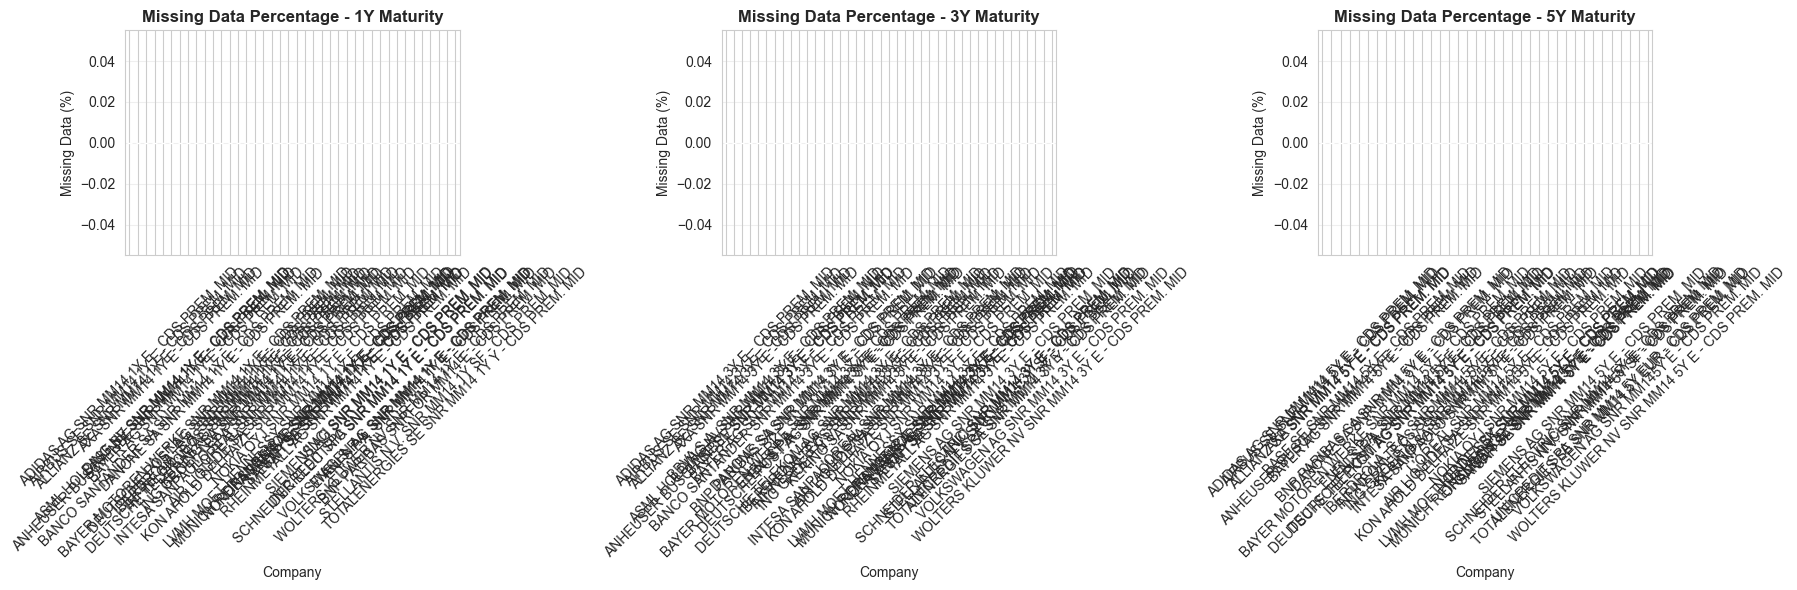

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (df, maturity, missing_df) in enumerate([
    (cds_1y, '1Y', missing_1y),
    (cds_3y, '3Y', missing_3y),
    (cds_5y, '5Y', missing_5y)
]):
    ax = axes[idx]
    missing_pct = missing_df.set_index('Company')['NA_Percentage']
    missing_pct.plot(kind='bar', ax=ax, color='coral')
    ax.set_title(f'Missing Data Percentage - {maturity} Maturity', fontsize=12, fontweight='bold')
    ax.set_xlabel('Company', fontsize=10)
    ax.set_ylabel('Missing Data (%)', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Sequential Repeat Analysis

In [7]:
def count_sequential_repeats(series):
    # Count consecutive unchanged values in a series
    clean_series = series.dropna()
    
    if len(clean_series) <= 1:
        return 0, 0, 0, 0
    
    changes = clean_series != clean_series.shift(1)
    groups = changes.cumsum()
    repeat_lengths = clean_series.groupby(groups).size()
    
    repeats = repeat_lengths[repeat_lengths > 1]
    total_repeats = (repeats - 1).sum()
    repeat_sequences = len(repeats)
    avg_repeat_length = repeats.mean() if len(repeats) > 0 else 0
    max_repeat_length = repeats.max() if len(repeats) > 0 else 0
    
    return total_repeats, repeat_sequences, avg_repeat_length, max_repeat_length

def analyze_sequential_repeats(df, maturity_name):
    # Compute repeat statistics for each company in the panel
    repeat_stats = []
    
    for company in df.columns:
        total_rep, seq_count, avg_len, max_len = count_sequential_repeats(df[company])
        valid_obs = df[company].notna().sum()
        
        repeat_stats.append({
            'Maturity': maturity_name,
            'Company': company,
            'Total_Repeats': total_rep,
            'Repeat_Sequences': seq_count,
            'Avg_Repeat_Length': avg_len,
            'Max_Repeat_Length': max_len,
            'Valid_Observations': valid_obs,
            'Repeat_Percentage': (total_rep / valid_obs * 100) if valid_obs > 0 else 0
        })
    
    return pd.DataFrame(repeat_stats)

repeats_1y = analyze_sequential_repeats(cds_1y, '1Y')
repeats_3y = analyze_sequential_repeats(cds_3y, '3Y')
repeats_5y = analyze_sequential_repeats(cds_5y, '5Y')

all_repeats = pd.concat([repeats_1y, repeats_3y, repeats_5y], ignore_index=True)

all_repeats

,Maturity,Company,Total_Repeats,Repeat_Sequences,Avg_Repeat_Length,Max_Repeat_Length,Valid_Observations,Repeat_Percentage
0,1Y,ADIDAS AG SNR MM14 1Y E - CDS PREM. MID,1368,200,7.8400,132,2348,58.2624
1,1Y,AIRBUS SE SNR MM14 1Y E - CDS PREM. MID,1338,249,6.3735,858,2348,56.9847
2,1Y,ALLIANZ SE SNR MM14 1Y E - CDS PREM. MID,310,235,2.3191,13,2348,13.2027
3,1Y,ANHEUSER-BUSCH INBE SNR MM14 1Y E - CDS PREM. MID,2347,1,2348.0000,2348,2348,99.9574
4,1Y,ASML HOLDING NV SNR MM14 1Y E - CDS PREM. MID,2274,51,45.5882,2086,2348,96.8484
...,...,...,...,...,...,...,...,...
113,5Y,TOTALENERGIES SE SNR MM14 5Y EUR - CDS PREM. MID,1239,128,10.6797,858,2348,52.7683
114,5Y,UNICREDIT SPA SNR MM14 5Y EUR - CDS PREM. MID,138,115,2.2000,7,2348,5.8773
115,5Y,VINCI SNR MM14 5Y E - CDS PREM. MID,271,200,2.3550,7,2348,11.5417
116,5Y,VOLKSWAGEN AG SNR MM145Y E - CDS PREM. MID,288,224,2.2857,6,2348,12.2658


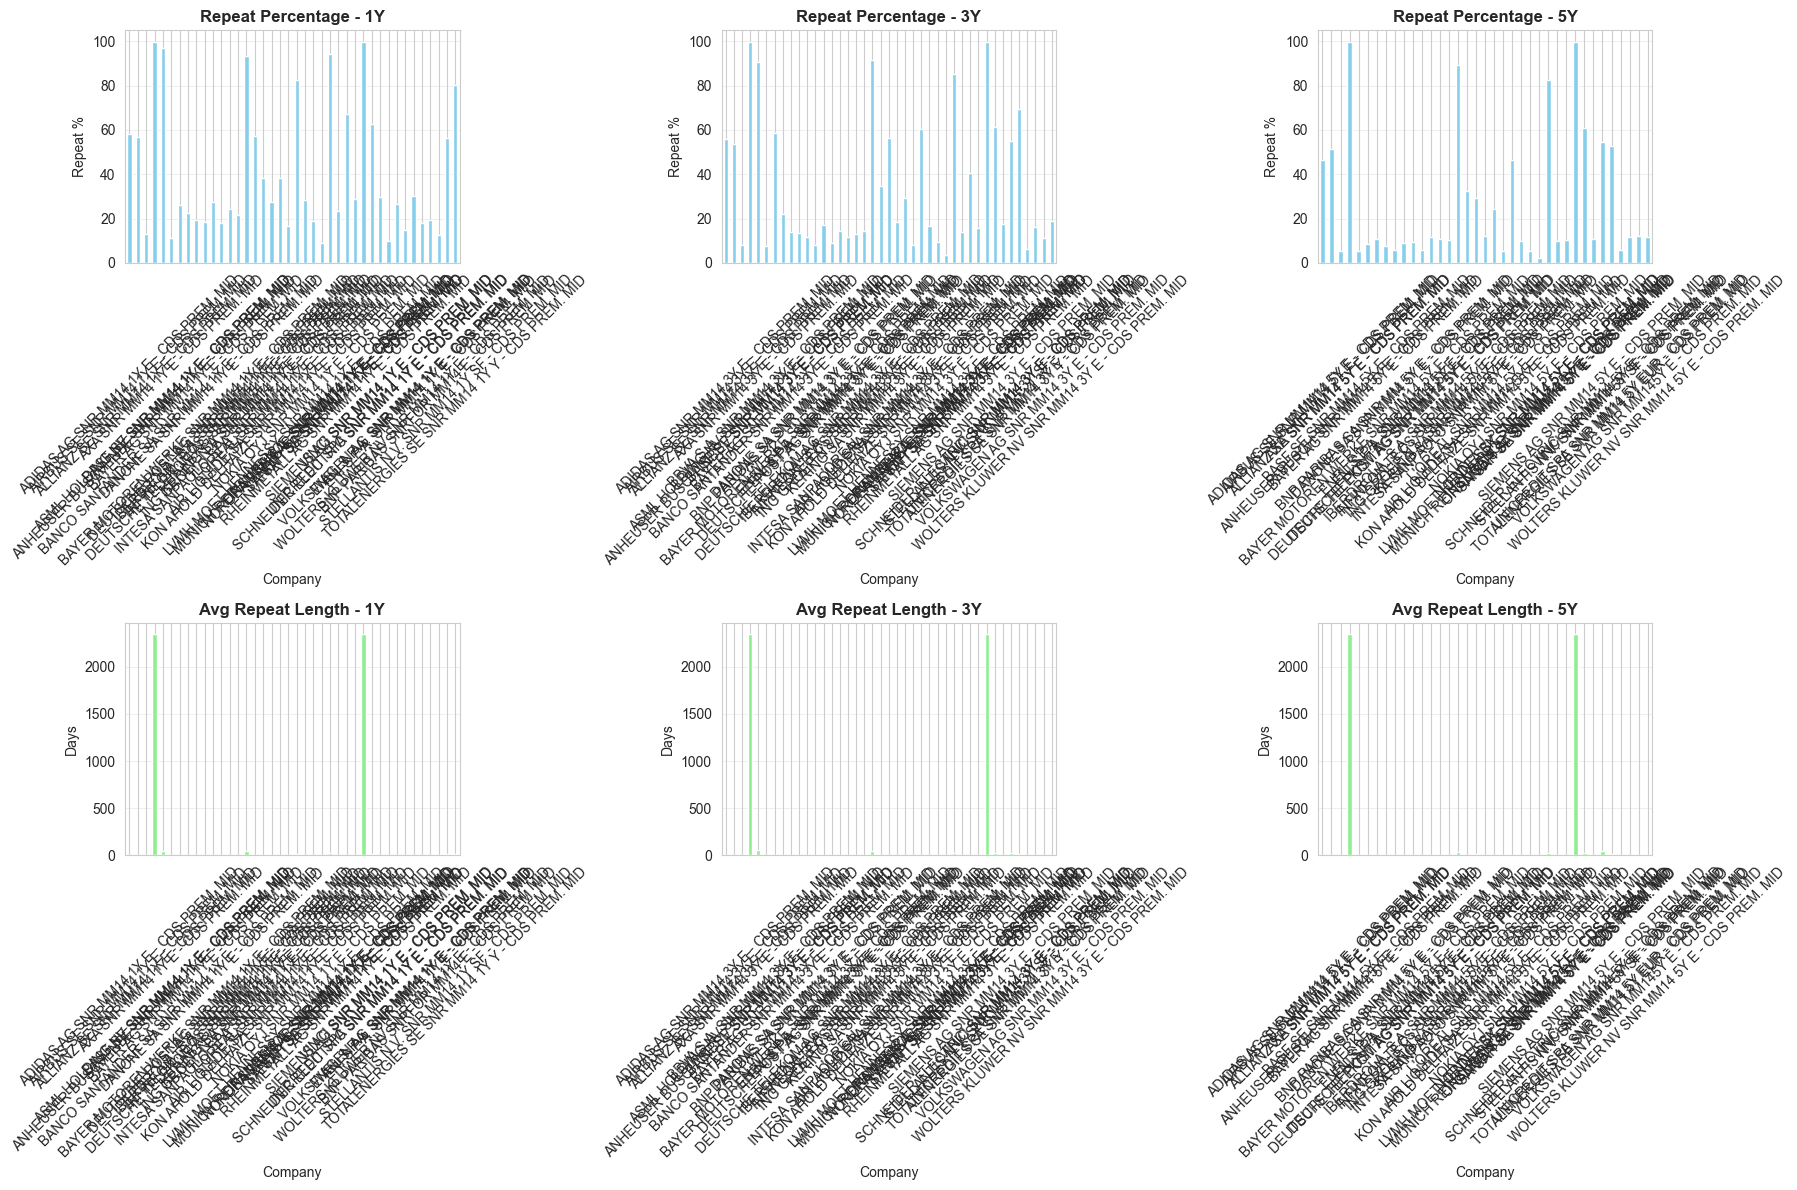

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, (maturity, repeat_df) in enumerate([
    ('1Y', repeats_1y),
    ('3Y', repeats_3y),
    ('5Y', repeats_5y)
]):
    ax1 = axes[0, idx]
    repeat_pct = repeat_df.set_index('Company')['Repeat_Percentage']
    repeat_pct.plot(kind='bar', ax=ax1, color='skyblue')
    ax1.set_title(f'Repeat Percentage - {maturity}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Company', fontsize=10)
    ax1.set_ylabel('Repeat %', fontsize=10)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    
    ax2 = axes[1, idx]
    avg_len = repeat_df.set_index('Company')['Avg_Repeat_Length']
    avg_len.plot(kind='bar', ax=ax2, color='lightgreen')
    ax2.set_title(f'Avg Repeat Length - {maturity}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Company', fontsize=10)
    ax2.set_ylabel('Days', fontsize=10)
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Liquidity Metrics

In [9]:
def calculate_liquidity_metrics(df, maturity_name):
    # Score each company's CDS liquidity based on availability, change frequency, and staleness
    liquidity_metrics = []
    
    for company in df.columns:
        series = df[company]
        total_obs = len(series)
        valid_obs = series.notna().sum()
        
        data_availability = (valid_obs / total_obs * 100) if total_obs > 0 else 0
        
        clean_series = series.dropna()
        if len(clean_series) > 1:
            changes = (clean_series != clean_series.shift(1)).sum() - 1
            change_frequency = (changes / (len(clean_series) - 1) * 100) if len(clean_series) > 1 else 0
        else:
            change_frequency = 0
        
        _, _, avg_len, max_len = count_sequential_repeats(series)
        
        # Weighted score 40% change frequency, 30% availability, 30% repeat penalty
        change_score = min(change_frequency, 100) * 0.4
        availability_score = data_availability * 0.3
        
        if avg_len > 0:
            repeat_score = max(0, 30 - (avg_len - 1) * 5)
        else:
            repeat_score = 30
        
        liquidity_score = change_score + availability_score + repeat_score
        
        liquidity_metrics.append({
            'Maturity': maturity_name,
            'Company': company,
            'Data_Availability_%': data_availability,
            'Change_Frequency_%': change_frequency,
            'Avg_Repeat_Length': avg_len,
            'Max_Repeat_Length': max_len,
            'Change_Score': change_score,
            'Availability_Score': availability_score,
            'Repeat_Score': repeat_score,
            'Liquidity_Score': liquidity_score
        })
    
    return pd.DataFrame(liquidity_metrics)

liquidity_1y = calculate_liquidity_metrics(cds_1y, '1Y')
liquidity_3y = calculate_liquidity_metrics(cds_3y, '3Y')
liquidity_5y = calculate_liquidity_metrics(cds_5y, '5Y')

all_liquidity = pd.concat([liquidity_1y, liquidity_3y, liquidity_5y], ignore_index=True)

all_liquidity

,Maturity,Company,Data_Availability_%,Change_Frequency_%,Avg_Repeat_Length,Max_Repeat_Length,Change_Score,Availability_Score,Repeat_Score,Liquidity_Score
0,1Y,ADIDAS AG SNR MM14 1Y E - CDS PREM. MID,100.0000,41.7128,7.8400,132,16.6851,30.0000,0.0000,46.6851
1,1Y,AIRBUS SE SNR MM14 1Y E - CDS PREM. MID,100.0000,42.9911,6.3735,858,17.1964,30.0000,3.1325,50.3290
2,1Y,ALLIANZ SE SNR MM14 1Y E - CDS PREM. MID,100.0000,86.7916,2.3191,13,34.7167,30.0000,23.4043,88.1209
3,1Y,ANHEUSER-BUSCH INBE SNR MM14 1Y E - CDS PREM. MID,100.0000,0.0000,2348.0000,2348,0.0000,30.0000,0.0000,30.0000
4,1Y,ASML HOLDING NV SNR MM14 1Y E - CDS PREM. MID,100.0000,3.1104,45.5882,2086,1.2441,30.0000,0.0000,31.2441
...,...,...,...,...,...,...,...,...,...,...
113,5Y,TOTALENERGIES SE SNR MM14 5Y EUR - CDS PREM. MID,100.0000,47.2092,10.6797,858,18.8837,30.0000,0.0000,48.8837
114,5Y,UNICREDIT SPA SNR MM14 5Y EUR - CDS PREM. MID,100.0000,94.1202,2.2000,7,37.6481,30.0000,24.0000,91.6481
115,5Y,VINCI SNR MM14 5Y E - CDS PREM. MID,100.0000,88.4533,2.3550,7,35.3813,30.0000,23.2250,88.6063
116,5Y,VOLKSWAGEN AG SNR MM145Y E - CDS PREM. MID,100.0000,87.7290,2.2857,6,35.0916,30.0000,23.5714,88.6630


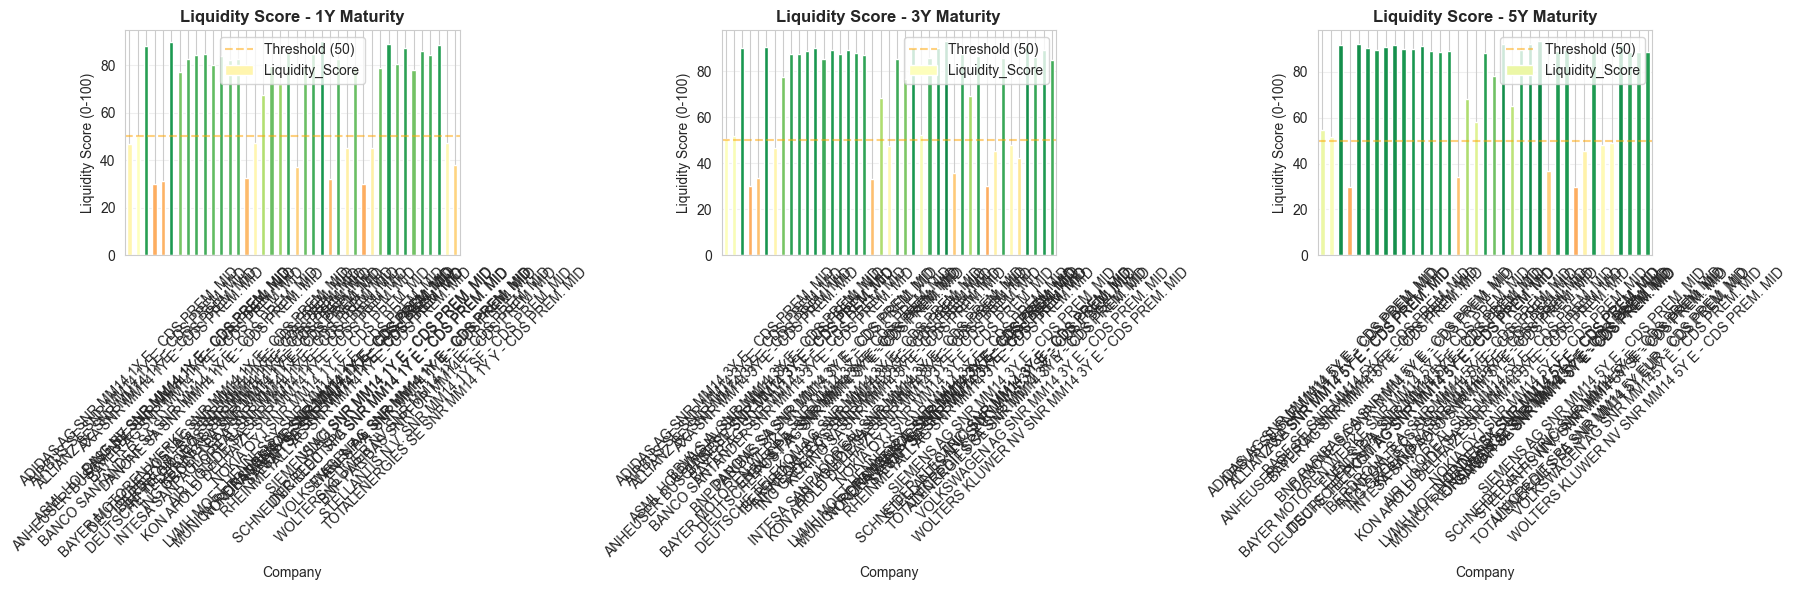

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (maturity, liq_df) in enumerate([
    ('1Y', liquidity_1y),
    ('3Y', liquidity_3y),
    ('5Y', liquidity_5y)
]):
    ax = axes[idx]
    liq_score = liq_df.set_index('Company')['Liquidity_Score']
    colors = plt.cm.RdYlGn(liq_score / 100)
    liq_score.plot(kind='bar', ax=ax, color=colors)
    ax.set_title(f'Liquidity Score - {maturity} Maturity', fontsize=12, fontweight='bold')
    ax.set_xlabel('Company', fontsize=10)
    ax.set_ylabel('Liquidity Score (0-100)', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(y=50, color='orange', linestyle='--', alpha=0.5, label='Threshold (50)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

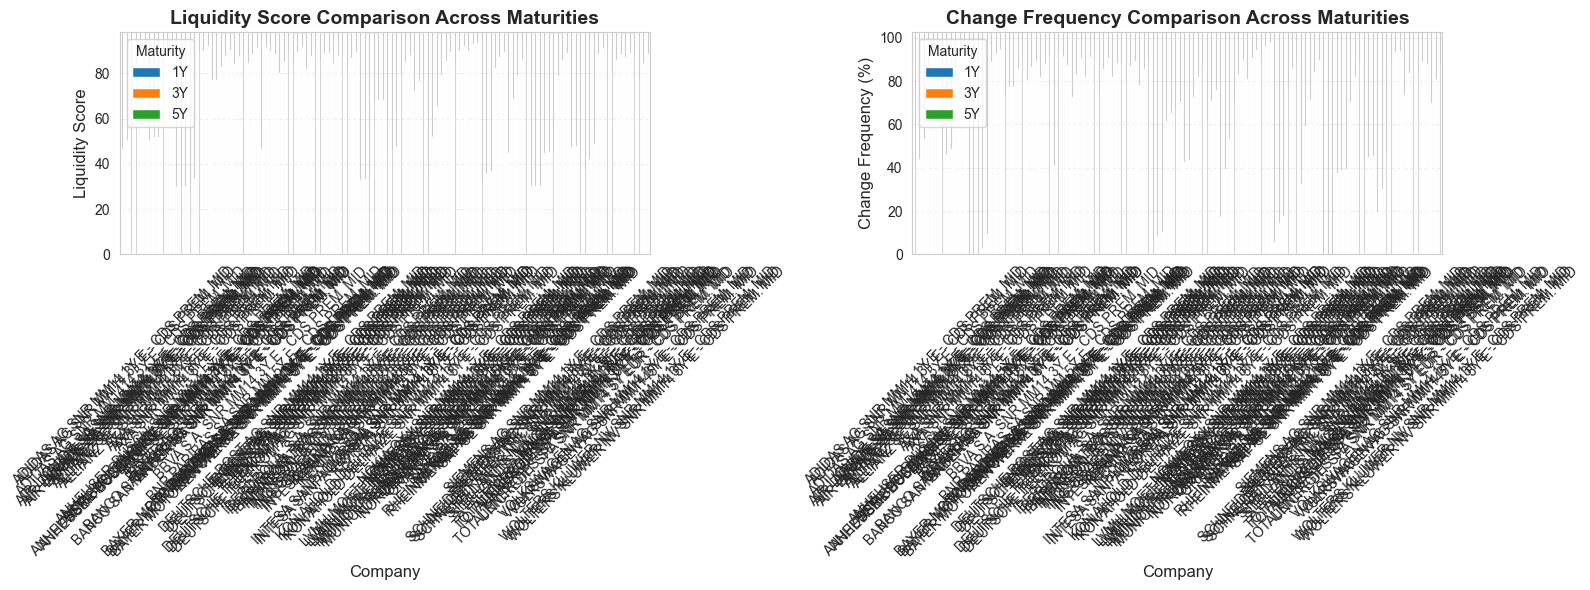

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
liquidity_pivot = all_liquidity.pivot(index='Company', columns='Maturity', values='Liquidity_Score')
liquidity_pivot.plot(kind='bar', ax=ax1)
ax1.set_title('Liquidity Score Comparison Across Maturities', fontsize=14, fontweight='bold')
ax1.set_xlabel('Company', fontsize=12)
ax1.set_ylabel('Liquidity Score', fontsize=12)
ax1.legend(title='Maturity', fontsize=10)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
change_pivot = all_liquidity.pivot(index='Company', columns='Maturity', values='Change_Frequency_%')
change_pivot.plot(kind='bar', ax=ax2)
ax2.set_title('Change Frequency Comparison Across Maturities', fontsize=14, fontweight='bold')
ax2.set_xlabel('Company', fontsize=12)
ax2.set_ylabel('Change Frequency (%)', fontsize=12)
ax2.legend(title='Maturity', fontsize=10)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Comprehensive Summary Report

In [12]:
comprehensive_summary = all_stats.merge(
    all_missing[['Maturity', 'Company', 'NA_Count', 'NA_Percentage']], 
    on=['Maturity', 'Company']
).merge(
    all_repeats[['Maturity', 'Company', 'Total_Repeats', 'Avg_Repeat_Length', 'Repeat_Percentage']], 
    on=['Maturity', 'Company']
).merge(
    all_liquidity[['Maturity', 'Company', 'Change_Frequency_%', 'Liquidity_Score']], 
    on=['Maturity', 'Company']
)

column_order = [
    'Company', 'Maturity', 'Count', 'NA_Count', 'NA_Percentage',
    'Mean', 'Median', 'Std', 'Min', 'Max', 'Range', 'CV',
    'Total_Repeats', 'Avg_Repeat_Length', 'Repeat_Percentage',
    'Change_Frequency_%', 'Liquidity_Score'
]
comprehensive_summary = comprehensive_summary[column_order]

comprehensive_summary

,Company,Maturity,Count,NA_Count,NA_Percentage,Mean,Median,Std,Min,Max,Range,CV,Total_Repeats,Avg_Repeat_Length,Repeat_Percentage,Change_Frequency_%,Liquidity_Score
0,ADIDAS AG SNR MM14 1Y E - CDS PREM. MID,1Y,2348,0,0.0000,29.8956,20.2800,19.4631,11.0400,68.0400,57.0000,0.6510,1368,7.8400,58.2624,41.7128,46.6851
1,AIRBUS SE SNR MM14 1Y E - CDS PREM. MID,1Y,2348,0,0.0000,32.6842,29.7600,22.7098,3.6600,197.0500,193.3900,0.6948,1338,6.3735,56.9847,42.9911,50.3290
2,ALLIANZ SE SNR MM14 1Y E - CDS PREM. MID,1Y,2348,0,0.0000,11.0821,9.3550,5.7143,3.8000,49.0200,45.2200,0.5156,310,2.3191,13.2027,86.7916,88.1209
3,ANHEUSER-BUSCH INBE SNR MM14 1Y E - CDS PREM. MID,1Y,2348,0,0.0000,30.6200,30.6200,0.0000,30.6200,30.6200,0.0000,0.0000,2347,2348.0000,99.9574,0.0000,30.0000
4,ASML HOLDING NV SNR MM14 1Y E - CDS PREM. MID,1Y,2348,0,0.0000,251.3873,251.5400,0.5581,248.4100,251.5400,3.1300,0.0022,2274,45.5882,96.8484,3.1104,31.2441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,TOTALENERGIES SE SNR MM14 5Y EUR - CDS PREM. MID,5Y,2348,0,0.0000,43.3884,43.5200,14.7340,20.1000,149.8500,129.7500,0.3396,1239,10.6797,52.7683,47.2092,48.8837
114,UNICREDIT SPA SNR MM14 5Y EUR - CDS PREM. MID,5Y,2348,0,0.0000,96.6725,85.5650,41.1231,37.0290,262.0500,225.0210,0.4254,138,2.2000,5.8773,94.1202,91.6481
115,VINCI SNR MM14 5Y E - CDS PREM. MID,5Y,2348,0,0.0000,42.0024,39.4150,11.3417,23.5700,91.1400,67.5700,0.2700,271,2.3550,11.5417,88.4533,88.6063
116,VOLKSWAGEN AG SNR MM145Y E - CDS PREM. MID,5Y,2348,0,0.0000,100.9979,95.7360,34.3314,48.0700,257.3000,209.2300,0.3399,288,2.2857,12.2658,87.7290,88.6630


In [13]:
output_dir = Path('../data/output')
output_dir.mkdir(exist_ok=True)

comprehensive_summary.to_csv(output_dir / 'cds_comprehensive_analysis.csv', index=False)
all_liquidity.to_csv(output_dir / 'cds_liquidity_metrics.csv', index=False)

## Insights and Rankings

In [14]:
for maturity in ['1Y', '3Y', '5Y']:
    maturity_data = all_liquidity[all_liquidity['Maturity'] == maturity].sort_values(
        'Liquidity_Score', ascending=False
    )[['Company', 'Liquidity_Score', 'Change_Frequency_%', 'Data_Availability_%']]
    display(maturity_data.reset_index(drop=True))

,Company,Liquidity_Score,Change_Frequency_%,Data_Availability_%
0,NOKIA OYJ SNR MM14 1Y E - CDS PREM. MID,90.0485,91.0098,100.0000
1,AXA SNR MM14 1Y E - CDS PREM. MID,89.6029,89.0072,100.0000
2,UNICREDIT SPA SNR MM14 1Y E - CDS PREM. MID,88.7019,90.0724,100.0000
3,BNP PARIBAS SNRFOR MM14 E - CDS PREM. MID,88.4061,87.6438,100.0000
4,ALLIANZ SE SNR MM14 1Y E - CDS PREM. MID,88.1209,86.7916,100.0000
5,VOLKSWAGEN AG SNR MM14 1Y E - CDS PREM. MID,87.2938,85.0447,100.0000
6,ENEL S.P.A. SNR MM14 1Y E - CDS PREM. MID,85.7172,81.9770,100.0000
7,AIR LIQUIDE SA SNR MM14 1Y E - CDS PREM. MID,85.4105,83.2552,100.0000
8,BAYER MOTOREN WERKE SNR MM14 1Y E - CDS PREM. MID,84.7502,81.7640,100.0000
9,MUNICH REINSURANCE SNR MM14 1Y E - CDS PREM. MID,84.6632,81.0396,100.0000


,Company,Liquidity_Score,Change_Frequency_%,Data_Availability_%
0,NOKIA OYJ SNR MM14 3Y E - CDS PREM. MID,93.0215,96.3357,100.0000
1,UNICREDIT SPA SNR MM14 3Y E - CDS PREM. MID,91.2380,93.5663,100.0000
2,AXA SNR MM14 3Y E - CDS PREM. MID,90.4876,92.5437,100.0000
3,MUNICH REINSURANCE SNR MM14 3Y E - CDS PREM. MID,90.2487,90.5411,100.0000
4,ALLIANZ SE SNR MM14 3Y E - CDS PREM. MID,90.1393,92.0750,100.0000
5,BNP PARIBAS SA SNR MM14 3Y E - CDS PREM. MID,89.9149,91.7767,100.0000
6,AIR LIQUIDE SA SNR MM14 3Y E - CDS PREM. MID,89.9149,91.7767,100.0000
7,DEUTSCHE POST AG SNR MM14 3Y E - CDS PREM. MID,89.2270,91.0098,100.0000
8,VOLKSWAGEN AG SNR MM14 3Y E - CDS PREM. MID,89.1632,88.6664,100.0000
9,ENEL S.P.A. SNR MM14 3Y E - CDS PREM. MID,89.0858,88.3681,100.0000


,Company,Liquidity_Score,Change_Frequency_%,Data_Availability_%
0,NOKIA OYJ SNR MM14 5Y E - CDS PREM. MID,93.4547,97.6992,100.0000
1,MUNICH REINSURANCE SNR MM14 5Y E - CDS PREM. MID,92.2045,94.5462,100.0000
2,AXA SNR MM14 5Y E - CDS PREM. MID,92.0640,94.8445,100.0000
3,AIR LIQUIDE SA SNR MM14 5Y E - CDS PREM. MID,92.0064,94.8445,100.0000
4,ALLIANZ SE SNR MM14 5Y E - CDS PREM. MID,91.8672,94.7167,100.0000
5,UNICREDIT SPA SNR MM14 5Y EUR - CDS PREM. MID,91.6481,94.1202,100.0000
6,BNP PARIBAS SA SNR MM 5Y E - CDS PREM. MID,91.5628,94.2480,100.0000
7,DEUTSCHE POST AG SNR MM14 5Y E - CDS PREM. MID,91.5125,94.2906,100.0000
8,BAYER MOTOREN WERKE SNR MM14 5Y E - CDS PREM. MID,91.0765,92.2880,100.0000
9,BASF SE SNR MM14 5Y E - CDS PREM. MID,90.5057,91.6915,100.0000


In [15]:
maturity_summary = all_liquidity.groupby('Maturity').agg({
    'Data_Availability_%': 'mean',
    'Change_Frequency_%': 'mean',
    'Avg_Repeat_Length': 'mean',
    'Max_Repeat_Length': 'mean',
    'Liquidity_Score': 'mean'
}).round(2)

maturity_summary

,Data_Availability_%,Change_Frequency_%,Avg_Repeat_Length,Max_Repeat_Length,Liquidity_Score
Maturity,,,,,
1Y,100.0000,60.0200,124.3500,420.6800,68.4800
3Y,100.0000,66.7300,121.6200,435.2200,72.0200
5Y,100.0000,73.5800,133.5700,363.3000,76.1400


In [16]:
liquidity_threshold = 50
missing_threshold = 10
repeat_threshold = 20

problematic = comprehensive_summary[
    (comprehensive_summary['Liquidity_Score'] < liquidity_threshold) |
    (comprehensive_summary['NA_Percentage'] > missing_threshold) |
    (comprehensive_summary['Repeat_Percentage'] > repeat_threshold)
].sort_values('Liquidity_Score')

problematic[[
    'Company', 'Maturity', 'NA_Percentage', 'Repeat_Percentage', 
    'Change_Frequency_%', 'Liquidity_Score'
]]

,Company,Maturity,NA_Percentage,Repeat_Percentage,Change_Frequency_%,Liquidity_Score
3,ANHEUSER-BUSCH INBE SNR MM14 1Y E - CDS PREM. MID,1Y,0.0000,99.9574,0.0000,30.0000
28,SAP SE SNR MM14 1Y E - CDS PREM. MID,1Y,0.0000,99.9574,0.0000,30.0000
43,ANHEUSER BUSCH INBEV SNR MM14 3Y E - CDS PREM....,3Y,0.0000,99.9574,0.0000,30.0000
84,ANHEUSER-BUSCH SNR MM14 5Y E - CDS PREM. MID,5Y,0.0000,99.9574,0.0000,30.0000
72,SAP SE SNR MM14 3Y E - CDS PREM. MID,3Y,0.0000,99.9574,0.0000,30.0000
109,SAP SE SNR MM14 5Y E - CDS PREM. MID,5Y,0.0000,99.9574,0.0000,30.0000
4,ASML HOLDING NV SNR MM14 1Y E - CDS PREM. MID,1Y,0.0000,96.8484,3.1104,31.2441
24,NORDEA BANK AB SNR MM14 1Y E - CDS PREM. MID,1Y,0.0000,94.2930,5.6668,32.2667
14,INFINEON TECS SNR MM14 1Y E - CDS PREM. MID,1Y,0.0000,93.3560,6.6042,32.6417
58,INFINEON TECS SNR MM14 3Y E - CDS PREM. MID,3Y,0.0000,91.6099,8.3511,33.3404


## Heatmap Visualizations

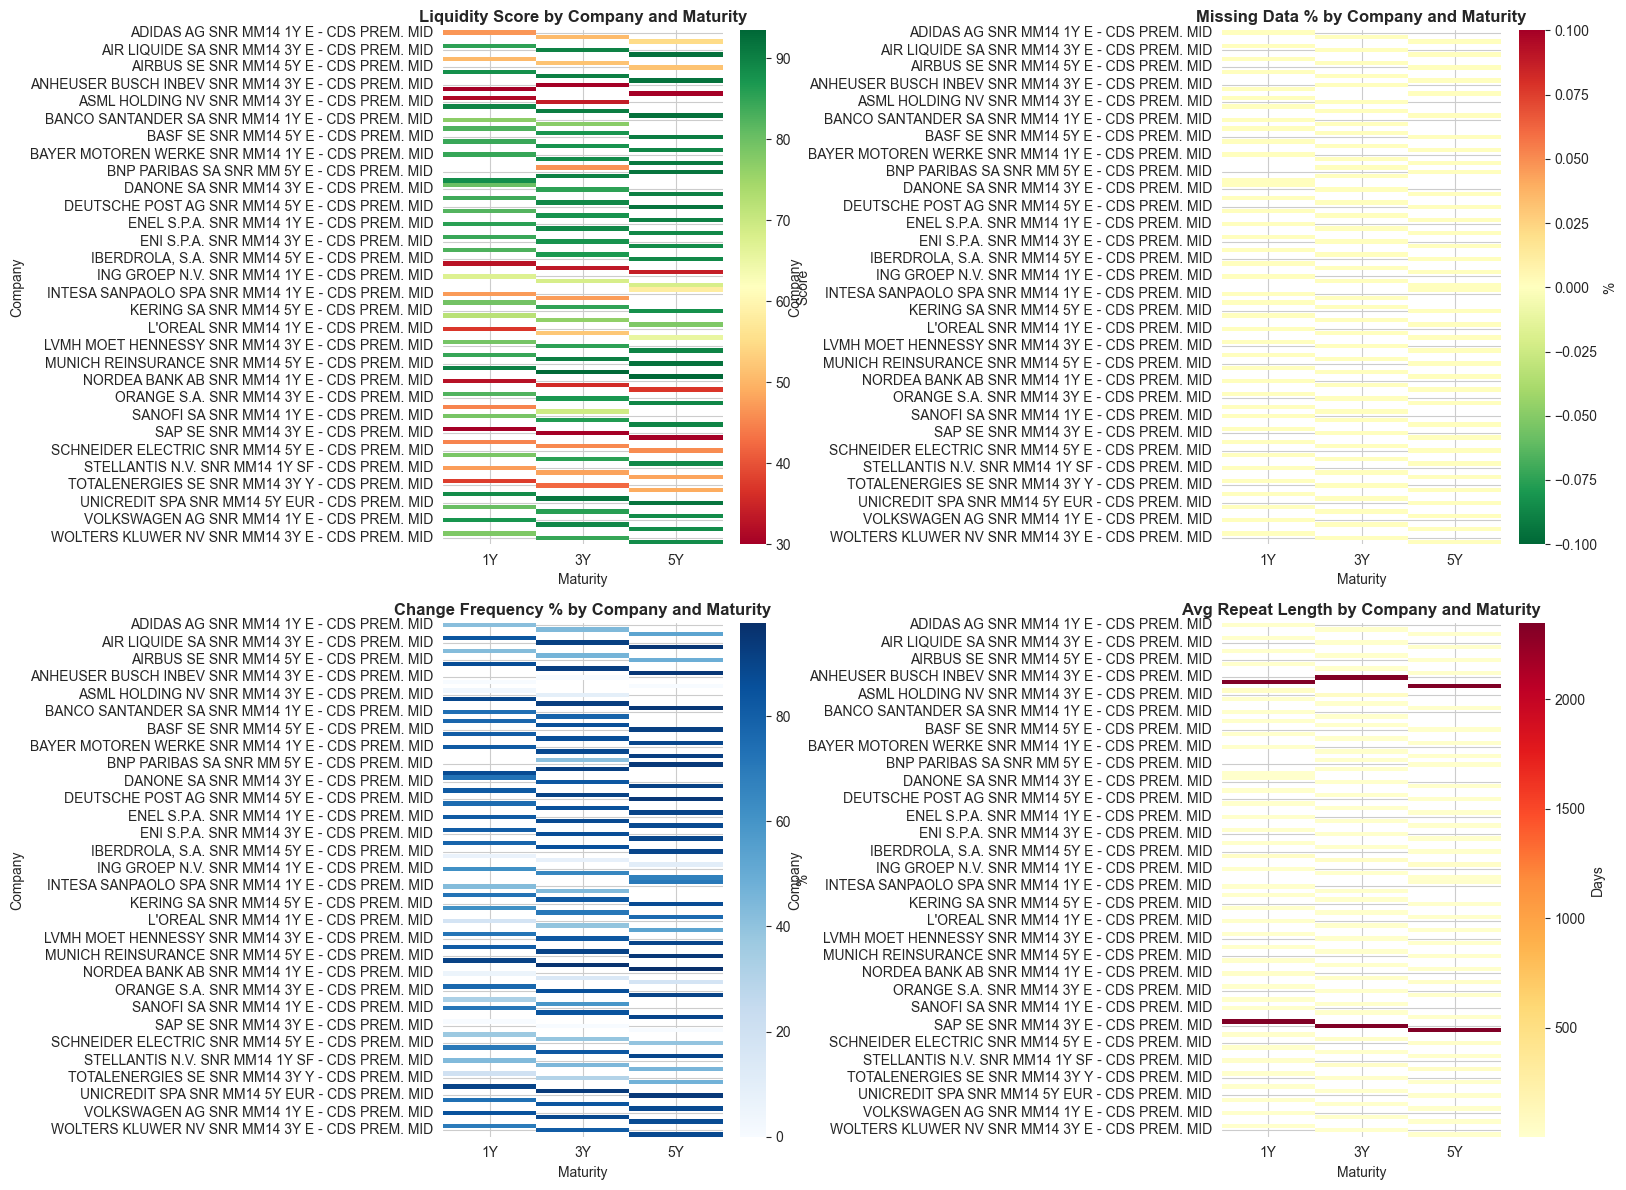

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
liq_heatmap = all_liquidity.pivot(index='Company', columns='Maturity', values='Liquidity_Score')
sns.heatmap(liq_heatmap, annot=False, cmap='RdYlGn', ax=ax1, cbar_kws={'label': 'Score'})
ax1.set_title('Liquidity Score by Company and Maturity', fontsize=12, fontweight='bold')

ax2 = axes[0, 1]
missing_heatmap = all_missing.pivot(index='Company', columns='Maturity', values='NA_Percentage')
sns.heatmap(missing_heatmap, annot=False, cmap='RdYlGn_r', ax=ax2, cbar_kws={'label': '%'})
ax2.set_title('Missing Data % by Company and Maturity', fontsize=12, fontweight='bold')

ax3 = axes[1, 0]
change_heatmap = all_liquidity.pivot(index='Company', columns='Maturity', values='Change_Frequency_%')
sns.heatmap(change_heatmap, annot=False, cmap='Blues', ax=ax3, cbar_kws={'label': '%'})
ax3.set_title('Change Frequency % by Company and Maturity', fontsize=12, fontweight='bold')

ax4 = axes[1, 1]
repeat_heatmap = all_liquidity.pivot(index='Company', columns='Maturity', values='Avg_Repeat_Length')
sns.heatmap(repeat_heatmap, annot=False, cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Days'})
ax4.set_title('Avg Repeat Length by Company and Maturity', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [18]:
screen = comprehensive_summary.copy()

liq_thr = 50
miss_thr = 10
rep_thr = 20

screen['Use_for_model'] = (
    (screen['Liquidity_Score'] >= liq_thr)
    & (screen['NA_Percentage'] <= miss_thr)
    & (screen['Repeat_Percentage'] <= rep_thr)
)

screen['High_confidence'] = (
    (screen['Liquidity_Score'] >= 70)
    & (screen['NA_Percentage'] <= 5)
    & (screen['Repeat_Percentage'] <= 15)
)

coverage = screen.groupby('Maturity').agg(
    total=('Company', 'count'),
    use_count=('Use_for_model', 'sum'),
    high_conf_count=('High_confidence', 'sum'),
    avg_liq=('Liquidity_Score', 'mean'),
    med_liq=('Liquidity_Score', 'median'),
    avg_missing=('NA_Percentage', 'mean'),
    avg_repeat=('Repeat_Percentage', 'mean')
)
coverage['use_pct'] = (coverage['use_count'] / coverage['total'] * 100).round(1)
coverage['high_conf_pct'] = (coverage['high_conf_count'] / coverage['total'] * 100).round(1)
coverage = coverage.round(2)

display(coverage)

worst = screen.sort_values('Liquidity_Score').loc[:, [
    'Company', 'Maturity', 'Liquidity_Score', 'NA_Percentage', 'Repeat_Percentage', 'Change_Frequency_%'
]].head(10)
display(worst)

best = screen.sort_values('Liquidity_Score', ascending=False).loc[:, [
    'Company', 'Maturity', 'Liquidity_Score', 'NA_Percentage', 'Repeat_Percentage', 'Change_Frequency_%'
]].head(10)
display(best)

fails = screen.groupby('Maturity').apply(
    lambda g: pd.Series({
        'fail_liquidity_lt_50': (g['Liquidity_Score'] < liq_thr).sum(),
        'fail_missing_gt_10pct': (g['NA_Percentage'] > miss_thr).sum(),
        'fail_repeat_gt_20pct': (g['Repeat_Percentage'] > rep_thr).sum(),
    })
)
display(fails)

,total,use_count,high_conf_count,avg_liq,med_liq,avg_missing,avg_repeat,use_pct,high_conf_pct
Maturity,,,,,,,,,
1Y,40,13,6,68.4800,79.4000,0.0000,39.9700,32.5000,15.0000
3Y,41,24,17,72.0200,85.4900,0.0000,33.2600,58.5000,41.5000
5Y,37,24,24,76.1400,89.0400,0.0000,26.4100,64.9000,64.9000


,Company,Maturity,Liquidity_Score,NA_Percentage,Repeat_Percentage,Change_Frequency_%
3,ANHEUSER-BUSCH INBE SNR MM14 1Y E - CDS PREM. MID,1Y,30.0000,0.0000,99.9574,0.0000
28,SAP SE SNR MM14 1Y E - CDS PREM. MID,1Y,30.0000,0.0000,99.9574,0.0000
43,ANHEUSER BUSCH INBEV SNR MM14 3Y E - CDS PREM....,3Y,30.0000,0.0000,99.9574,0.0000
72,SAP SE SNR MM14 3Y E - CDS PREM. MID,3Y,30.0000,0.0000,99.9574,0.0000
84,ANHEUSER-BUSCH SNR MM14 5Y E - CDS PREM. MID,5Y,30.0000,0.0000,99.9574,0.0000
109,SAP SE SNR MM14 5Y E - CDS PREM. MID,5Y,30.0000,0.0000,99.9574,0.0000
4,ASML HOLDING NV SNR MM14 1Y E - CDS PREM. MID,1Y,31.2441,0.0000,96.8484,3.1104
24,NORDEA BANK AB SNR MM14 1Y E - CDS PREM. MID,1Y,32.2667,0.0000,94.2930,5.6668
14,INFINEON TECS SNR MM14 1Y E - CDS PREM. MID,1Y,32.6417,0.0000,93.3560,6.6042
58,INFINEON TECS SNR MM14 3Y E - CDS PREM. MID,3Y,33.3404,0.0000,91.6099,8.3511


,Company,Maturity,Liquidity_Score,NA_Percentage,Repeat_Percentage,Change_Frequency_%
105,NOKIA OYJ SNR MM14 5Y E - CDS PREM. MID,5Y,93.4547,0.0000,2.2998,97.6992
67,NOKIA OYJ SNR MM14 3Y E - CDS PREM. MID,3Y,93.0215,0.0000,3.6627,96.3357
104,MUNICH REINSURANCE SNR MM14 5Y E - CDS PREM. MID,5Y,92.2045,0.0000,5.4514,94.5462
85,AXA SNR MM14 5Y E - CDS PREM. MID,5Y,92.0640,0.0000,5.1533,94.8445
101,AIR LIQUIDE SA SNR MM14 5Y E - CDS PREM. MID,5Y,92.0064,0.0000,5.1533,94.8445
83,ALLIANZ SE SNR MM14 5Y E - CDS PREM. MID,5Y,91.8672,0.0000,5.2811,94.7167
114,UNICREDIT SPA SNR MM14 5Y EUR - CDS PREM. MID,5Y,91.6481,0.0000,5.8773,94.1202
89,BNP PARIBAS SA SNR MM 5Y E - CDS PREM. MID,5Y,91.5628,0.0000,5.7496,94.2480
92,DEUTSCHE POST AG SNR MM14 5Y E - CDS PREM. MID,5Y,91.5125,0.0000,5.7070,94.2906
77,UNICREDIT SPA SNR MM14 3Y E - CDS PREM. MID,3Y,91.2380,0.0000,6.4310,93.5663


,fail_liquidity_lt_50,fail_missing_gt_10pct,fail_repeat_gt_20pct
Maturity,,,
1Y,12,0,27
3Y,10,0,17
5Y,7,0,13


### Model Usability

In [19]:
# Check for unnamed columns
for maturity, df in [('1Y', cds_1y), ('3Y', cds_3y), ('5Y', cds_5y)]:
    cols = pd.Series(df.columns.astype(str))
    unnamed = cols.str.startswith('Unnamed:').sum()

In [20]:
for nm in ['cds_1y', 'cds_3y', 'cds_5y']:
    df = globals()[nm]
    dup_mask = pd.Index(df.columns).duplicated(keep='first')
    dup_count = int(dup_mask.sum())
    if dup_count > 0:
        globals()[nm] = df.loc[:, ~dup_mask]

## Date-Level Liquidity Screening

In [21]:
# Configuration for rolling-window liquidity screening
screen_cfg = {
    'window_obs': 60,
    'min_window_obs': 45,
    'min_availability': 0.90,
    'min_change_frequency': 0.25,
    'max_stale_days': 10,
    'min_segment_years': 3,
}

cfg_table = pd.DataFrame([
    {'Rule': 'window_obs', 'Value': screen_cfg['window_obs'], 'Meaning': 'Rolling window length (observations)'},
    {'Rule': 'min_window_obs', 'Value': screen_cfg['min_window_obs'], 'Meaning': 'Minimum observations required in rolling window'},
    {'Rule': 'min_availability', 'Value': screen_cfg['min_availability'], 'Meaning': 'Minimum non-missing ratio in rolling window'},
    {'Rule': 'min_change_frequency', 'Value': screen_cfg['min_change_frequency'], 'Meaning': 'Minimum fraction of non-zero day-to-day changes'},
    {'Rule': 'max_stale_days', 'Value': screen_cfg['max_stale_days'], 'Meaning': 'Maximum consecutive unchanged observed days'},
    {'Rule': 'min_segment_years', 'Value': screen_cfg['min_segment_years'], 'Meaning': 'Minimum contiguous good calendar years to keep segment'},
])

maturity_panels = {
    '1Y': cds_1y.loc[:, ~pd.Index(cds_1y.columns).duplicated(keep='first')],
    '3Y': cds_3y.loc[:, ~pd.Index(cds_3y.columns).duplicated(keep='first')],
    '5Y': cds_5y.loc[:, ~pd.Index(cds_5y.columns).duplicated(keep='first')],
}


def _stale_days(series):
    # Count consecutive days where the spread value is unchanged
    out = np.full(len(series), np.nan)
    last_val = np.nan
    streak = 0
    for i, val in enumerate(series.to_numpy()):
        if pd.isna(val):
            out[i] = np.nan
            continue
        if pd.isna(last_val) or val != last_val:
            streak = 0
        else:
            streak += 1
        out[i] = streak
        last_val = val
    return pd.Series(out, index=series.index)


def _series_date_flags(series, maturity, company, cfg):
    # Flag each date as good/bad based on rolling availability, change frequency, staleness
    s = pd.to_numeric(series, errors='coerce').sort_index()
    valid = s.notna()

    changed = (s != s.shift(1)) & valid & s.shift(1).notna()

    rolling_valid = valid.astype(float).rolling(cfg['window_obs'], min_periods=cfg['min_window_obs']).mean()
    valid_count = valid.astype(float).rolling(cfg['window_obs'], min_periods=cfg['min_window_obs']).sum()
    change_count = changed.astype(float).rolling(cfg['window_obs'], min_periods=cfg['min_window_obs']).sum()
    rolling_change_freq = change_count / (valid_count - 1).clip(lower=1)

    stale_days = _stale_days(s)

    # Apply each exclusion criterion
    fail_missing = ~valid
    fail_low_avail = valid & (rolling_valid < cfg['min_availability'])
    fail_low_change = valid & (rolling_change_freq < cfg['min_change_frequency'])
    fail_stale = valid & (stale_days > cfg['max_stale_days'])

    good = valid & (~fail_low_avail) & (~fail_low_change) & (~fail_stale)

    reason = np.where(fail_missing, 'missing', '')
    reason = np.where((reason == '') & fail_low_avail, 'low_availability', reason)
    reason = np.where((reason == '') & fail_low_change, 'low_change_frequency', reason)
    reason = np.where((reason == '') & fail_stale, 'stale_quote', reason)
    reason = np.where(reason == '', 'good', reason)

    combo = (
        fail_missing.map({True: 'missing', False: ''}).astype(str)
        + fail_low_avail.map({True: '|low_availability', False: ''}).astype(str)
        + fail_low_change.map({True: '|low_change_frequency', False: ''}).astype(str)
        + fail_stale.map({True: '|stale_quote', False: ''}).astype(str)
    ).str.lstrip('|')
    combo = combo.replace('', 'good')

    return pd.DataFrame({
        'Date': s.index,
        'Maturity': maturity,
        'Company': company,
        'Spread': s.values,
        'Is_Valid': valid.values,
        'Rolling_Availability': rolling_valid.values,
        'Rolling_Change_Frequency': rolling_change_freq.values,
        'Stale_Days': stale_days.values,
        'Fail_Missing': fail_missing.values,
        'Fail_Low_Availability': fail_low_avail.values,
        'Fail_Low_Change': fail_low_change.values,
        'Fail_Stale': fail_stale.values,
        'Is_Good_Day': good.values,
        'Primary_Reason': reason,
        'Reason_Combo': combo.values,
    })

# Run date-level screening for every company and maturity
all_flags = []
for mty, panel in maturity_panels.items():
    for comp in panel.columns:
        all_flags.append(_series_date_flags(panel[comp], mty, comp, screen_cfg))

cds_date_flags = pd.concat(all_flags, ignore_index=True)


def _extract_segments(flags_df, min_segment_years):
    # Find contiguous good-day segments and keep only those longer than min years
    out = []
    min_days = int(min_segment_years * 365)
    for (mty, comp), g in flags_df.groupby(['Maturity', 'Company'], sort=False):
        gs = g.sort_values('Date').copy()
        block = gs['Is_Good_Day'].ne(gs['Is_Good_Day'].shift()).cumsum()
        gs['_block'] = block

        for _, seg in gs.groupby('_block'):
            is_good = bool(seg['Is_Good_Day'].iloc[0])
            start = seg['Date'].iloc[0]
            end = seg['Date'].iloc[-1]
            n_obs = len(seg)
            segment_days = int((end - start).days)
            if is_good:
                out.append({
                    'Maturity': mty,
                    'Company': comp,
                    'Segment_Start': start,
                    'Segment_End': end,
                    'Segment_Obs': n_obs,
                    'Segment_Days': segment_days,
                    'Keep_For_Model': segment_days >= min_days,
                })
    return pd.DataFrame(out)


good_segments = _extract_segments(cds_date_flags, screen_cfg['min_segment_years'])

# Summarize quality per series total obs, good obs, kept segments
series_quality = cds_date_flags.groupby(['Maturity', 'Company']).agg(
    Total_Obs=('Date', 'count'),
    Good_Obs=('Is_Good_Day', 'sum'),
    First_Date=('Date', 'min'),
    Last_Date=('Date', 'max'),
).reset_index()
series_quality['Good_Pct'] = (series_quality['Good_Obs'] / series_quality['Total_Obs'] * 100).round(2)

kept_segments = good_segments[good_segments['Keep_For_Model']].copy()
series_keep_summary = kept_segments.groupby(['Maturity', 'Company']).agg(
    Kept_Segments=('Keep_For_Model', 'count'),
    Kept_Obs=('Segment_Obs', 'sum'),
    Kept_Start=('Segment_Start', 'min'),
    Kept_End=('Segment_End', 'max'),
).reset_index()

series_quality = series_quality.merge(series_keep_summary, on=['Maturity', 'Company'], how='left')
series_quality['Kept_Segments'] = series_quality['Kept_Segments'].fillna(0).astype(int)
series_quality['Kept_Obs'] = series_quality['Kept_Obs'].fillna(0).astype(int)
series_quality['Kept_Pct'] = (series_quality['Kept_Obs'] / series_quality['Total_Obs'] * 100).round(2)
series_quality['Exclude_All'] = series_quality['Kept_Obs'].eq(0)

display(cfg_table)
display(series_quality.sort_values(['Exclude_All', 'Kept_Pct', 'Good_Pct'], ascending=[False, True, True]).head(15))

,Rule,Value,Meaning
0,window_obs,60.0000,Rolling window length (observations)
1,min_window_obs,45.0000,Minimum observations required in rolling window
2,min_availability,0.9000,Minimum non-missing ratio in rolling window
3,min_change_frequency,0.2500,Minimum fraction of non-zero day-to-day changes
4,max_stale_days,10.0000,Maximum consecutive unchanged observed days
5,min_segment_years,3.0000,Minimum contiguous good calendar years to keep...


,Maturity,Company,Total_Obs,Good_Obs,First_Date,Last_Date,Good_Pct,Kept_Segments,Kept_Obs,Kept_Start,Kept_End,Kept_Pct,Exclude_All
4,1Y,ANHEUSER-BUSCH INBE SNR MM14 1Y E - CDS PREM. MID,2348,11,2017-01-02,2025-12-31,0.4700,0,0,NaT,NaT,0.0000,True
31,1Y,SAP SE SNR MM14 1Y E - CDS PREM. MID,2348,11,2017-01-02,2025-12-31,0.4700,0,0,NaT,NaT,0.0000,True
44,3Y,ANHEUSER BUSCH INBEV SNR MM14 3Y E - CDS PREM....,2348,11,2017-01-02,2025-12-31,0.4700,0,0,NaT,NaT,0.0000,True
72,3Y,SAP SE SNR MM14 3Y E - CDS PREM. MID,2348,11,2017-01-02,2025-12-31,0.4700,0,0,NaT,NaT,0.0000,True
85,5Y,ANHEUSER-BUSCH SNR MM14 5Y E - CDS PREM. MID,2348,11,2017-01-02,2025-12-31,0.4700,0,0,NaT,NaT,0.0000,True
109,5Y,SAP SE SNR MM14 5Y E - CDS PREM. MID,2348,11,2017-01-02,2025-12-31,0.4700,0,0,NaT,NaT,0.0000,True
18,1Y,INFINEON TECS SNR MM14 1Y E - CDS PREM. MID,2348,184,2017-01-02,2025-12-31,7.8400,0,0,NaT,NaT,0.0000,True
5,1Y,ASML HOLDING NV SNR MM14 1Y E - CDS PREM. MID,2348,200,2017-01-02,2025-12-31,8.5200,0,0,NaT,NaT,0.0000,True
27,1Y,NORDEA BANK AB SNR MM14 1Y E - CDS PREM. MID,2348,244,2017-01-02,2025-12-31,10.3900,0,0,NaT,NaT,0.0000,True
59,3Y,INFINEON TECS SNR MM14 3Y E - CDS PREM. MID,2348,259,2017-01-02,2025-12-31,11.0300,0,0,NaT,NaT,0.0000,True


In [22]:
reason_breakdown = (
    cds_date_flags[~cds_date_flags['Is_Good_Day']]
    .groupby(['Maturity', 'Primary_Reason'])
    .size()
    .rename('Excluded_Days')
    .reset_index()
)

exclude_series = series_quality[series_quality['Exclude_All']].sort_values(['Maturity', 'Company'])
partial_series = series_quality[(~series_quality['Exclude_All']) & (series_quality['Kept_Pct'] < 100)].sort_values(['Maturity', 'Kept_Pct'])
full_series = series_quality[series_quality['Kept_Pct'] == 100].sort_values(['Maturity', 'Company'])

keep_windows = kept_segments.sort_values(['Maturity', 'Company', 'Segment_Start'])

final_date_panel = cds_date_flags.merge(
    keep_windows[['Maturity', 'Company', 'Segment_Start', 'Segment_End']],
    on=['Maturity', 'Company'],
    how='left'
)
final_date_panel['In_Kept_Window'] = (
    (final_date_panel['Date'] >= final_date_panel['Segment_Start'])
    & (final_date_panel['Date'] <= final_date_panel['Segment_End'])
)
final_date_panel['In_Kept_Window'] = final_date_panel['In_Kept_Window'].fillna(False)
final_date_panel['Use_For_Model'] = final_date_panel['Is_Good_Day'] & final_date_panel['In_Kept_Window']

final_date_panel = (
    final_date_panel
    .groupby(['Date', 'Maturity', 'Company', 'Spread', 'Is_Valid', 'Rolling_Availability',
              'Rolling_Change_Frequency', 'Stale_Days', 'Fail_Missing', 'Fail_Low_Availability',
              'Fail_Low_Change', 'Fail_Stale', 'Is_Good_Day', 'Primary_Reason', 'Reason_Combo'], as_index=False)
    .agg(Use_For_Model=('Use_For_Model', 'max'))
)

display(exclude_series[['Maturity', 'Company', 'Good_Pct', 'Kept_Pct', 'Good_Obs', 'Kept_Obs']])
display(partial_series[['Maturity', 'Company', 'Good_Pct', 'Kept_Pct', 'Kept_Segments', 'Kept_Start', 'Kept_End']].head(25))
display(keep_windows.head(40))
display(reason_breakdown)

output_dir = Path('../data/output')
output_dir.mkdir(exist_ok=True)

cfg_table.to_csv(output_dir / 'cds_liquidity_screen_config.csv', index=False)
series_quality.to_csv(output_dir / 'cds_series_quality_screen.csv', index=False)
keep_windows.to_csv(output_dir / 'cds_keep_windows_by_series.csv', index=False)
exclude_series.to_csv(output_dir / 'cds_exclude_series.csv', index=False)
reason_breakdown.to_csv(output_dir / 'cds_exclusion_reason_breakdown.csv', index=False)
final_date_panel.to_csv(output_dir / 'cds_date_level_model_use_flag.csv', index=False)

,Maturity,Company,Good_Pct,Kept_Pct,Good_Obs,Kept_Obs
0,1Y,ADIDAS AG SNR MM14 1Y E - CDS PREM. MID,57.3300,0.0000,1346,0
2,1Y,AIRBUS SE SNR MM14 1Y E - CDS PREM. MID,63.5900,0.0000,1493,0
4,1Y,ANHEUSER-BUSCH INBE SNR MM14 1Y E - CDS PREM. MID,0.4700,0.0000,11,0
5,1Y,ASML HOLDING NV SNR MM14 1Y E - CDS PREM. MID,8.5200,0.0000,200,0
18,1Y,INFINEON TECS SNR MM14 1Y E - CDS PREM. MID,7.8400,0.0000,184,0
23,1Y,L'OREAL SNR MM14 1Y E - CDS PREM. MID,27.8500,0.0000,654,0
27,1Y,NORDEA BANK AB SNR MM14 1Y E - CDS PREM. MID,10.3900,0.0000,244,0
29,1Y,RHEINMETALL AG SNR MM14 1Y E - CDS PREM. MID,46.8500,0.0000,1100,0
31,1Y,SAP SE SNR MM14 1Y E - CDS PREM. MID,0.4700,0.0000,11,0
32,1Y,SCHNEIDER ELECTRIC SNR MM14 1Y E - CDS PREM. MID,43.5300,0.0000,1022,0


,Maturity,Company,Good_Pct,Kept_Pct,Kept_Segments,Kept_Start,Kept_End
7,1Y,BANCO SANTANDER SA SNR MM14 1Y E - CDS PREM. MID,92.5000,36.1600,1,2017-01-02,2020-04-02
22,1Y,KON AHOLD DELHAIZE SNR MM14 1Y E - CDS PREM. MID,90.9700,43.3100,1,2017-09-20,2021-08-12
34,1Y,STELLANTIS N.V. SNR MM14 1Y SF - CDS PREM. MID,47.4000,47.4000,1,2017-01-02,2021-04-07
25,1Y,MUNICH REINSURANCE SNR MM14 1Y E - CDS PREM. MID,99.8700,48.5500,1,2021-08-19,2025-12-31
20,1Y,INTESA SANPAOLO SPA SNR MM14 1Y E - CDS PREM. MID,54.4700,54.4700,1,2017-01-02,2021-11-25
19,1Y,ING GROEP N.V. SNR MM14 1Y E - CDS PREM. MID,81.1800,54.6000,1,2017-01-02,2021-11-30
39,1Y,WOLTERS KLUWER NV SNR MM14 1Y E - CDS PREM. MID,99.6200,84.7500,1,2018-05-17,2025-12-31
14,1Y,DEUTSCHE TELEKOM AG SNR MM14 1Y E - CDS PREM. MID,99.9600,88.8000,1,2018-01-04,2025-12-31
24,1Y,LVMH MOET HENNESSY SNR MM14 1Y E - CDS PREM. MID,99.8300,89.0100,1,2017-12-28,2025-12-31
21,1Y,KERING SA SNR MM14 1Y E - CDS PREM. MID,99.1900,92.8000,2,2017-01-02,2025-05-09


,Maturity,Company,Segment_Start,Segment_End,Segment_Obs,Segment_Days,Keep_For_Model
59,1Y,AIR LIQUIDE SA SNR MM14 1Y E - CDS PREM. MID,2017-01-02,2021-09-14,1227,1716,True
60,1Y,AIR LIQUIDE SA SNR MM14 1Y E - CDS PREM. MID,2021-09-20,2025-12-31,1118,1563,True
15,1Y,ALLIANZ SE SNR MM14 1Y E - CDS PREM. MID,2017-01-02,2021-08-16,1206,1687,True
16,1Y,ALLIANZ SE SNR MM14 1Y E - CDS PREM. MID,2021-08-19,2025-12-31,1140,1595,True
24,1Y,AXA SNR MM14 1Y E - CDS PREM. MID,2017-01-02,2025-12-31,2348,3285,True
25,1Y,BANCO SANTANDER SA SNR MM14 1Y E - CDS PREM. MID,2017-01-02,2020-04-02,849,1186,True
29,1Y,BASF SE SNR MM14 1Y E - CDS PREM. MID,2017-01-02,2025-12-31,2348,3285,True
30,1Y,BAYER AG SNR MM14 1Y E - CDS PREM. MID,2017-01-02,2025-12-31,2348,3285,True
31,1Y,BAYER MOTOREN WERKE SNR MM14 1Y E - CDS PREM. MID,2017-01-02,2025-12-31,2348,3285,True
135,1Y,BNP PARIBAS SNRFOR MM14 E - CDS PREM. MID,2017-01-02,2025-12-31,2348,3285,True


,Maturity,Primary_Reason,Excluded_Days
0,1Y,low_change_frequency,21051
1,1Y,stale_quote,819
2,3Y,low_change_frequency,19841
3,3Y,stale_quote,778
4,5Y,low_change_frequency,14870
5,5Y,stale_quote,652


### Exclusion Breakdown & Export

In [23]:
series_profile = series_quality[['Maturity', 'Company', 'Total_Obs', 'Good_Obs', 'Good_Pct', 'Kept_Obs', 'Kept_Pct', 'Kept_Segments', 'Kept_Start', 'Kept_End', 'First_Date', 'Last_Date']].copy()

series_profile['Pattern'] = np.select(
    [
        series_profile['Kept_Obs'].eq(0),
        (series_profile['Kept_Start'] <= series_profile['First_Date']) & (series_profile['Kept_End'] < series_profile['Last_Date']),
        (series_profile['Kept_Start'] > series_profile['First_Date']) & (series_profile['Kept_End'] >= series_profile['Last_Date']),
        (series_profile['Kept_Start'] > series_profile['First_Date']) & (series_profile['Kept_End'] < series_profile['Last_Date']),
        (series_profile['Kept_Start'] <= series_profile['First_Date']) & (series_profile['Kept_End'] >= series_profile['Last_Date']),
    ],
    [
        'Exclude_All',
        'Good_Early_Then_Degrade',
        'Bad_Early_Then_Good',
        'Good_Middle_Only',
        'Good_Most_Of_Sample',
    ],
    default='Mixed'
)

pattern_summary = series_profile.groupby(['Maturity', 'Pattern']).size().rename('Series_Count').reset_index()

display(pattern_summary.sort_values(['Maturity', 'Series_Count'], ascending=[True, False]))

display(series_profile[series_profile['Pattern'] == 'Good_Early_Then_Degrade']
        .sort_values(['Maturity', 'Kept_End'])
        .head(15))

display(series_profile[series_profile['Pattern'] == 'Bad_Early_Then_Good']
        .sort_values(['Maturity', 'Kept_Start'])
        .head(15))

display(series_profile[series_profile['Pattern'] == 'Good_Middle_Only']
        .sort_values(['Maturity', 'Kept_Pct'])
        .head(15))

,Maturity,Pattern,Series_Count
4,1Y,Good_Most_Of_Sample,14
1,1Y,Exclude_All,11
0,1Y,Bad_Early_Then_Good,7
2,1Y,Good_Early_Then_Degrade,7
3,1Y,Good_Middle_Only,1
8,3Y,Good_Most_Of_Sample,22
6,3Y,Good_Early_Then_Degrade,10
5,3Y,Exclude_All,8
7,3Y,Good_Middle_Only,1
12,5Y,Good_Most_Of_Sample,22


,Maturity,Company,Total_Obs,Good_Obs,Good_Pct,Kept_Obs,Kept_Pct,Kept_Segments,Kept_Start,Kept_End,First_Date,Last_Date,Pattern
7,1Y,BANCO SANTANDER SA SNR MM14 1Y E - CDS PREM. MID,2348,2172,92.5000,849,36.1600,1,2017-01-02,2020-04-02,2017-01-02,2025-12-31,Good_Early_Then_Degrade
34,1Y,STELLANTIS N.V. SNR MM14 1Y SF - CDS PREM. MID,2348,1113,47.4000,1113,47.4000,1,2017-01-02,2021-04-07,2017-01-02,2025-12-31,Good_Early_Then_Degrade
20,1Y,INTESA SANPAOLO SPA SNR MM14 1Y E - CDS PREM. MID,2348,1279,54.4700,1279,54.4700,1,2017-01-02,2021-11-25,2017-01-02,2025-12-31,Good_Early_Then_Degrade
19,1Y,ING GROEP N.V. SNR MM14 1Y E - CDS PREM. MID,2348,1906,81.1800,1282,54.6000,1,2017-01-02,2021-11-30,2017-01-02,2025-12-31,Good_Early_Then_Degrade
21,1Y,KERING SA SNR MM14 1Y E - CDS PREM. MID,2348,2329,99.1900,2179,92.8000,2,2017-01-02,2025-05-09,2017-01-02,2025-12-31,Good_Early_Then_Degrade
36,1Y,UNICREDIT SPA SNR MM14 1Y E - CDS PREM. MID,2348,2346,99.9100,2344,99.8300,1,2017-01-02,2025-12-25,2017-01-02,2025-12-31,Good_Early_Then_Degrade
17,1Y,"IBERDROLA, S.A. SNR MM14 1Y E - CDS PREM. MID",2348,2345,99.8700,2345,99.8700,1,2017-01-02,2025-12-26,2017-01-02,2025-12-31,Good_Early_Then_Degrade
76,3Y,TOTALENERGIES SE SNR MM14 3Y Y - CDS PREM. MID,2348,950,40.4600,950,40.4600,1,2017-01-02,2020-08-21,2017-01-02,2025-12-31,Good_Early_Then_Degrade
75,3Y,STELLANTIS N.V. SNR MM14 3Y SF - CDS PREM. MID,2348,1113,47.4000,1113,47.4000,1,2017-01-02,2021-04-07,2017-01-02,2025-12-31,Good_Early_Then_Degrade
63,3Y,KON AHOLD DELHAIZE SNR MM14 3Y E - CDS PREM. MID,2348,2141,91.1800,1131,48.1700,1,2017-01-02,2021-05-03,2017-01-02,2025-12-31,Good_Early_Then_Degrade


,Maturity,Company,Total_Obs,Good_Obs,Good_Pct,Kept_Obs,Kept_Pct,Kept_Segments,Kept_Start,Kept_End,First_Date,Last_Date,Pattern
12,1Y,DANONE SA SNR MM14 1Y E - CDS PREM. MID,2348,2347,99.9600,2271,96.7200,1,2017-04-19,2025-12-31,2017-01-02,2025-12-31,Bad_Early_Then_Good
33,1Y,SIEMENS AG SNR MM14 1Y E - CDS PREM. MID,2348,2340,99.6600,2268,96.5900,1,2017-04-24,2025-12-31,2017-01-02,2025-12-31,Bad_Early_Then_Good
37,1Y,VINCI SNR MM14 1Y E - CDS PREM. MID,2348,2344,99.8300,2236,95.2300,1,2017-06-07,2025-12-31,2017-01-02,2025-12-31,Bad_Early_Then_Good
24,1Y,LVMH MOET HENNESSY SNR MM14 1Y E - CDS PREM. MID,2348,2344,99.8300,2090,89.0100,1,2017-12-28,2025-12-31,2017-01-02,2025-12-31,Bad_Early_Then_Good
14,1Y,DEUTSCHE TELEKOM AG SNR MM14 1Y E - CDS PREM. MID,2348,2347,99.9600,2085,88.8000,1,2018-01-04,2025-12-31,2017-01-02,2025-12-31,Bad_Early_Then_Good
39,1Y,WOLTERS KLUWER NV SNR MM14 1Y E - CDS PREM. MID,2348,2339,99.6200,1990,84.7500,1,2018-05-17,2025-12-31,2017-01-02,2025-12-31,Bad_Early_Then_Good
25,1Y,MUNICH REINSURANCE SNR MM14 1Y E - CDS PREM. MID,2348,2345,99.8700,1140,48.5500,1,2021-08-19,2025-12-31,2017-01-02,2025-12-31,Bad_Early_Then_Good


,Maturity,Company,Total_Obs,Good_Obs,Good_Pct,Kept_Obs,Kept_Pct,Kept_Segments,Kept_Start,Kept_End,First_Date,Last_Date,Pattern
22,1Y,KON AHOLD DELHAIZE SNR MM14 1Y E - CDS PREM. MID,2348,2136,90.9700,1017,43.3100,1,2017-09-20,2021-08-12,2017-01-02,2025-12-31,Good_Middle_Only
42,3Y,AIRBUS SE SNR MM14 3Y E - CDS PREM. MID,2348,1493,63.5900,1398,59.5400,1,2017-05-24,2022-09-30,2017-01-02,2025-12-31,Good_Middle_Only
102,5Y,L'OREAL SNR MM14 5Y E - CDS PREM. MID,2348,1948,82.9600,825,35.1400,1,2021-08-25,2024-10-22,2017-01-02,2025-12-31,Good_Middle_Only
81,5Y,ADIDAS AG SNR MM1414 5Y E - CDS PREM. MID,2348,1530,65.1600,1369,58.3000,1,2020-02-11,2025-05-09,2017-01-02,2025-12-31,Good_Middle_Only
83,5Y,AIRBUS SE SNR MM14 5Y E - CDS PREM. MID,2348,1494,63.6300,1399,59.5800,1,2017-05-24,2022-10-03,2017-01-02,2025-12-31,Good_Middle_Only


### Series Quality Profiles

In [24]:
exclude_counts = series_quality.groupby('Maturity').agg(
    total_series=('Company', 'count'),
    fully_excluded=('Exclude_All', 'sum'),
    partially_used=('Kept_Pct', lambda x: ((x > 0) & (x < 100)).sum()),
    fully_used=('Kept_Pct', lambda x: (x == 100).sum()),
).reset_index()
exclude_counts['fully_excluded_pct'] = (exclude_counts['fully_excluded'] / exclude_counts['total_series'] * 100).round(1)

display(exclude_counts)

early_cut = (
    series_profile[series_profile['Pattern'] == 'Good_Early_Then_Degrade']
    .sort_values('Kept_End')
    [['Maturity', 'Company', 'Kept_Start', 'Kept_End', 'Kept_Pct']]
    .head(10)
)
display(early_cut)

late_start = (
    series_profile[series_profile['Pattern'] == 'Bad_Early_Then_Good']
    .sort_values('Kept_Start', ascending=False)
    [['Maturity', 'Company', 'Kept_Start', 'Kept_End', 'Kept_Pct']]
    .head(10)
)
display(late_start)

,Maturity,total_series,fully_excluded,partially_used,fully_used,fully_excluded_pct
0,1Y,40,11,19,10,27.5000
1,3Y,41,8,11,22,19.5000
2,5Y,37,5,10,22,13.5000


,Maturity,Company,Kept_Start,Kept_End,Kept_Pct
7,1Y,BANCO SANTANDER SA SNR MM14 1Y E - CDS PREM. MID,2017-01-02,2020-04-02,36.1600
76,3Y,TOTALENERGIES SE SNR MM14 3Y Y - CDS PREM. MID,2017-01-02,2020-08-21,40.4600
113,5Y,TOTALENERGIES SE SNR MM14 5Y EUR - CDS PREM. MID,2017-01-02,2020-08-21,40.4600
75,3Y,STELLANTIS N.V. SNR MM14 3Y SF - CDS PREM. MID,2017-01-02,2021-04-07,47.4000
34,1Y,STELLANTIS N.V. SNR MM14 1Y SF - CDS PREM. MID,2017-01-02,2021-04-07,47.4000
112,5Y,STELLANTIS N.V. SNR MM14 5Y SF - CDS PREM. MID,2017-01-02,2021-04-07,47.4000
63,3Y,KON AHOLD DELHAIZE SNR MM14 3Y E - CDS PREM. MID,2017-01-02,2021-05-03,48.1700
51,3Y,BBVA S.A. SNR MM14 3Y E - CDS PREM. MID,2017-01-02,2021-11-25,54.4700
20,1Y,INTESA SANPAOLO SPA SNR MM14 1Y E - CDS PREM. MID,2017-01-02,2021-11-25,54.4700
61,3Y,INTESA SANPAOLO SPA SNR MM14 3Y E - CDS PREM. MID,2017-01-02,2021-11-25,54.4700


,Maturity,Company,Kept_Start,Kept_End,Kept_Pct
25,1Y,MUNICH REINSURANCE SNR MM14 1Y E - CDS PREM. MID,2021-08-19,2025-12-31,48.5500
39,1Y,WOLTERS KLUWER NV SNR MM14 1Y E - CDS PREM. MID,2018-05-17,2025-12-31,84.7500
14,1Y,DEUTSCHE TELEKOM AG SNR MM14 1Y E - CDS PREM. MID,2018-01-04,2025-12-31,88.8000
24,1Y,LVMH MOET HENNESSY SNR MM14 1Y E - CDS PREM. MID,2017-12-28,2025-12-31,89.0100
37,1Y,VINCI SNR MM14 1Y E - CDS PREM. MID,2017-06-07,2025-12-31,95.2300
33,1Y,SIEMENS AG SNR MM14 1Y E - CDS PREM. MID,2017-04-24,2025-12-31,96.5900
12,1Y,DANONE SA SNR MM14 1Y E - CDS PREM. MID,2017-04-19,2025-12-31,96.7200


In [25]:
cds_model_panel_long = (
    final_date_panel.loc[
        final_date_panel['Use_For_Model'],
        ['Date', 'Maturity', 'Company', 'Spread', 'Rolling_Availability', 'Rolling_Change_Frequency', 'Stale_Days']
    ]
    .sort_values(['Date', 'Maturity', 'Company'])
    .reset_index(drop=True)
)

cds_model_panel_wide = {}
for mty, g in cds_model_panel_long.groupby('Maturity'):
    cds_model_panel_wide[mty] = g.pivot(index='Date', columns='Company', values='Spread').sort_index()

coverage_final = (
    cds_model_panel_long.groupby('Maturity')
    .agg(
        kept_rows=('Spread', 'size'),
        kept_firms=('Company', 'nunique'),
        start=('Date', 'min'),
        end=('Date', 'max')
    )
    .reset_index()
)

display(coverage_final)
display(cds_model_panel_long.head(20))

,Maturity,kept_rows,kept_firms,start,end
0,1Y,58273,29,2017-03-03,2025-12-31
1,3Y,66910,33,2017-03-03,2025-12-31
2,5Y,65088,32,2017-03-03,2025-12-31


,Date,Maturity,Company,Spread,Rolling_Availability,Rolling_Change_Frequency,Stale_Days
0,2017-03-03,1Y,AIR LIQUIDE SA SNR MM14 1Y E - CDS PREM. MID,11.2900,1.0000,0.4545,0.0000
1,2017-03-03,1Y,ALLIANZ SE SNR MM14 1Y E - CDS PREM. MID,13.8100,1.0000,0.7955,0.0000
2,2017-03-03,1Y,AXA SNR MM14 1Y E - CDS PREM. MID,26.0600,1.0000,0.9773,0.0000
3,2017-03-03,1Y,BANCO SANTANDER SA SNR MM14 1Y E - CDS PREM. MID,20.9500,1.0000,0.9318,0.0000
4,2017-03-03,1Y,BASF SE SNR MM14 1Y E - CDS PREM. MID,9.4600,1.0000,0.3409,0.0000
5,2017-03-03,1Y,BAYER AG SNR MM14 1Y E - CDS PREM. MID,7.8500,1.0000,0.4545,0.0000
6,2017-03-03,1Y,BAYER MOTOREN WERKE SNR MM14 1Y E - CDS PREM. MID,9.9200,1.0000,0.5455,1.0000
7,2017-03-03,1Y,BNP PARIBAS SNRFOR MM14 E - CDS PREM. MID,32.9500,1.0000,0.9773,0.0000
8,2017-03-03,1Y,DEUTSCHE POST AG SNR MM14 1Y E - CDS PREM. MID,8.7400,1.0000,0.9545,0.0000
9,2017-03-03,1Y,ENEL S.P.A. SNR MM14 1Y E - CDS PREM. MID,24.2100,1.0000,0.7045,0.0000


### Final Model Panel

In [26]:
# Verify no pre-2017 data leaked into the final panel
cutoff_date = pd.Timestamp('2017-01-01')

min_date_in_panel = cds_model_panel_long['Date'].min()
if min_date_in_panel < cutoff_date:
    raise ValueError(f"Found dates before cutoff in final panel: {min_date_in_panel}")

cds_model_panel_long_post2017 = cds_model_panel_long.copy()

coverage_post2017 = (
    cds_model_panel_long_post2017.groupby('Maturity')
    .agg(
        kept_rows=('Spread', 'size'),
        kept_firms=('Company', 'nunique'),
        start=('Date', 'min'),
        end=('Date', 'max')
    )
    .reset_index()
)

display(coverage_post2017)

filter_dir = Path('../data/cds_filters')
filter_dir.mkdir(parents=True, exist_ok=True)
gvkey_maturity_windows_path = filter_dir / 'gvkey_maturity_simulation_windows.csv'
cleaned_cds_path = filter_dir / 'cds_clean_for_comparison.csv'

# Remove old filter files 
for old_file in filter_dir.glob('*.csv'):
    if old_file.name not in {gvkey_maturity_windows_path.name, cleaned_cds_path.name}:
        try:
            old_file.unlink()
        except PermissionError:
            print(f"WARNING: Could not remove locked file {old_file.name}")

import re

def _normalize_company_name(name):
    # Strip legal suffixes and punctuation to produce company name for matching
    legal = {
        'SA','SPA','SE','AG','NV','OYJ','GROUP','HOLDING','HOLDINGS','PLC','INC','CORP','CORPORATION',
        'CO','COMPANY','LTD','LIMITED','REINSURANCE','N','V','S','P','A'
    }
    s = str(name).upper()
    s = re.sub(r'\bSNR.*$', '', s)
    s = re.sub(r'\bSUB.*$', '', s)
    s = re.sub(r'\bMM\d+.*$', '', s)
    s = re.sub(r'\bCDS\b.*$', '', s)
    s = s.replace('PREM', ' ').replace('MID', ' ')
    s = re.sub(r'[^A-Z0-9 ]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    toks = [t for t in s.split() if t and t not in legal and not t.isdigit() and len(t) > 1]
    return ' '.join(toks), tuple(sorted(set(toks)))

merton_map_path = Path('../data/output/merged_data_with_merton.csv')
if not merton_map_path.exists():
    raise FileNotFoundError(f"Required file not found for gvkey mapping: {merton_map_path}")

# Get the set of (date, company) pairs that passed the liquidity screen
allowed_company_dates = (
    final_date_panel.loc[final_date_panel['Use_For_Model'], ['Date', 'Maturity', 'Company', 'Spread']]
    .rename(columns={'Date': 'date', 'Company': 'cds_company'})
    .copy()
)
allowed_company_dates['date'] = pd.to_datetime(allowed_company_dates['date'], errors='coerce').dt.normalize()
allowed_company_dates = allowed_company_dates[
    allowed_company_dates['date'].notna()
    & allowed_company_dates['cds_company'].notna()
].drop_duplicates()

# Map CDS company names to gvkeys via Merton output file
merton_map = pd.read_csv(merton_map_path, usecols=['company', 'gvkey'])
merton_map = merton_map[merton_map['company'].notna() & merton_map['gvkey'].notna()].drop_duplicates().copy()

cds_names = pd.DataFrame({'cds_company': sorted(allowed_company_dates['cds_company'].unique())})
cds_names[['norm_name', 'norm_tokens']] = cds_names['cds_company'].apply(lambda x: pd.Series(_normalize_company_name(x)))

merton_names = merton_map[['company', 'gvkey']].drop_duplicates().copy()
merton_names[['norm_name', 'norm_tokens']] = merton_names['company'].apply(lambda x: pd.Series(_normalize_company_name(x)))

# First pass, exact normalized name match
exact = cds_names.merge(
    merton_names[['company', 'gvkey', 'norm_name']].drop_duplicates(),
    on='norm_name',
    how='left'
)

# Second pass, token overlap fallback for unmatched names
fallback_rows = []
unmatched_exact = exact[exact['gvkey'].isna()][['cds_company', 'norm_tokens']].copy()
for _, row in unmatched_exact.iterrows():
    tok_set = set(row['norm_tokens'])
    if not tok_set:
        continue
    best = None
    for _, cand in merton_names.iterrows():
        cand_set = set(cand['norm_tokens'])
        if not cand_set:
            continue
        inter = len(tok_set & cand_set)
        if inter == 0:
            continue
        score = inter / max(len(tok_set), len(cand_set))
        if best is None or score > best[0]:
            best = (score, cand['company'], cand['gvkey'])
    if best is not None and best[0] >= 0.50:
        fallback_rows.append({
            'cds_company': row['cds_company'],
            'mapped_company': best[1],
            'gvkey': best[2],
            'match_score': best[0],
            'match_type': 'token_overlap'
        })

fallback = pd.DataFrame(fallback_rows) if fallback_rows else pd.DataFrame(
    columns=['cds_company', 'mapped_company', 'gvkey', 'match_score', 'match_type']
)

mapped_exact = exact[exact['gvkey'].notna()][['cds_company', 'company', 'gvkey']].drop_duplicates()
mapped_exact = mapped_exact.rename(columns={'company': 'mapped_company'})
mapped_exact['match_type'] = 'exact_norm'
mapped_exact['match_score'] = 1.0

mapped = pd.concat([mapped_exact, fallback], ignore_index=True)
mapped = mapped.drop_duplicates(subset=['cds_company'], keep='first')

# Build final cleaned CDS panel with gvkey identifiers
cleaned_cds = (
    allowed_company_dates
    .merge(mapped[['cds_company', 'mapped_company', 'gvkey', 'match_type', 'match_score']], on='cds_company', how='inner')
    [['date', 'Maturity', 'cds_company', 'mapped_company', 'gvkey', 'Spread', 'match_type', 'match_score']]
    .rename(columns={'Maturity': 'maturity', 'Spread': 'spread'})
    .drop_duplicates()
    .sort_values(['date', 'gvkey', 'maturity'])
)

# Build per-gvkey simulation windows (date ranges per maturity)
maturity_to_horizon = {'1Y': 252, '3Y': 756, '5Y': 1260}
gvkey_maturity_windows = (
    cleaned_cds.assign(maturity=lambda d: d['maturity'].astype(str).str.upper().str.strip())
    .groupby(['gvkey', 'maturity'], as_index=False)
    .agg(start_date=('date', 'min'), end_date=('date', 'max'))
)
gvkey_maturity_windows['horizon_days'] = gvkey_maturity_windows['maturity'].map(maturity_to_horizon)
gvkey_maturity_windows = gvkey_maturity_windows[
    gvkey_maturity_windows['horizon_days'].notna()
].sort_values(['gvkey', 'horizon_days'])

cleaned_cds.to_csv(cleaned_cds_path, index=False)
gvkey_maturity_windows.to_csv(gvkey_maturity_windows_path, index=False)

display(gvkey_maturity_windows.head(20))

,Maturity,kept_rows,kept_firms,start,end
0,1Y,58273,29,2017-03-03,2025-12-31
1,3Y,66910,33,2017-03-03,2025-12-31
2,5Y,65088,32,2017-03-03,2025-12-31


,gvkey,maturity,start_date,end_date,horizon_days
0,14447.0000,1Y,2017-12-28,2025-12-31,252
1,14447.0000,3Y,2017-03-03,2025-12-31,756
2,14447.0000,5Y,2017-03-03,2025-12-31,1260
3,15532.0000,1Y,2017-03-03,2025-12-31,252
4,15532.0000,3Y,2017-03-03,2025-12-31,756
5,15532.0000,5Y,2017-03-03,2025-12-31,1260
6,15549.0000,1Y,2017-03-03,2025-12-25,252
7,15549.0000,3Y,2017-03-03,2025-12-31,756
8,15549.0000,5Y,2017-03-03,2025-12-31,1260
9,15617.0000,1Y,2017-03-03,2021-11-30,252


### Data Validation & GVKEY Mapping

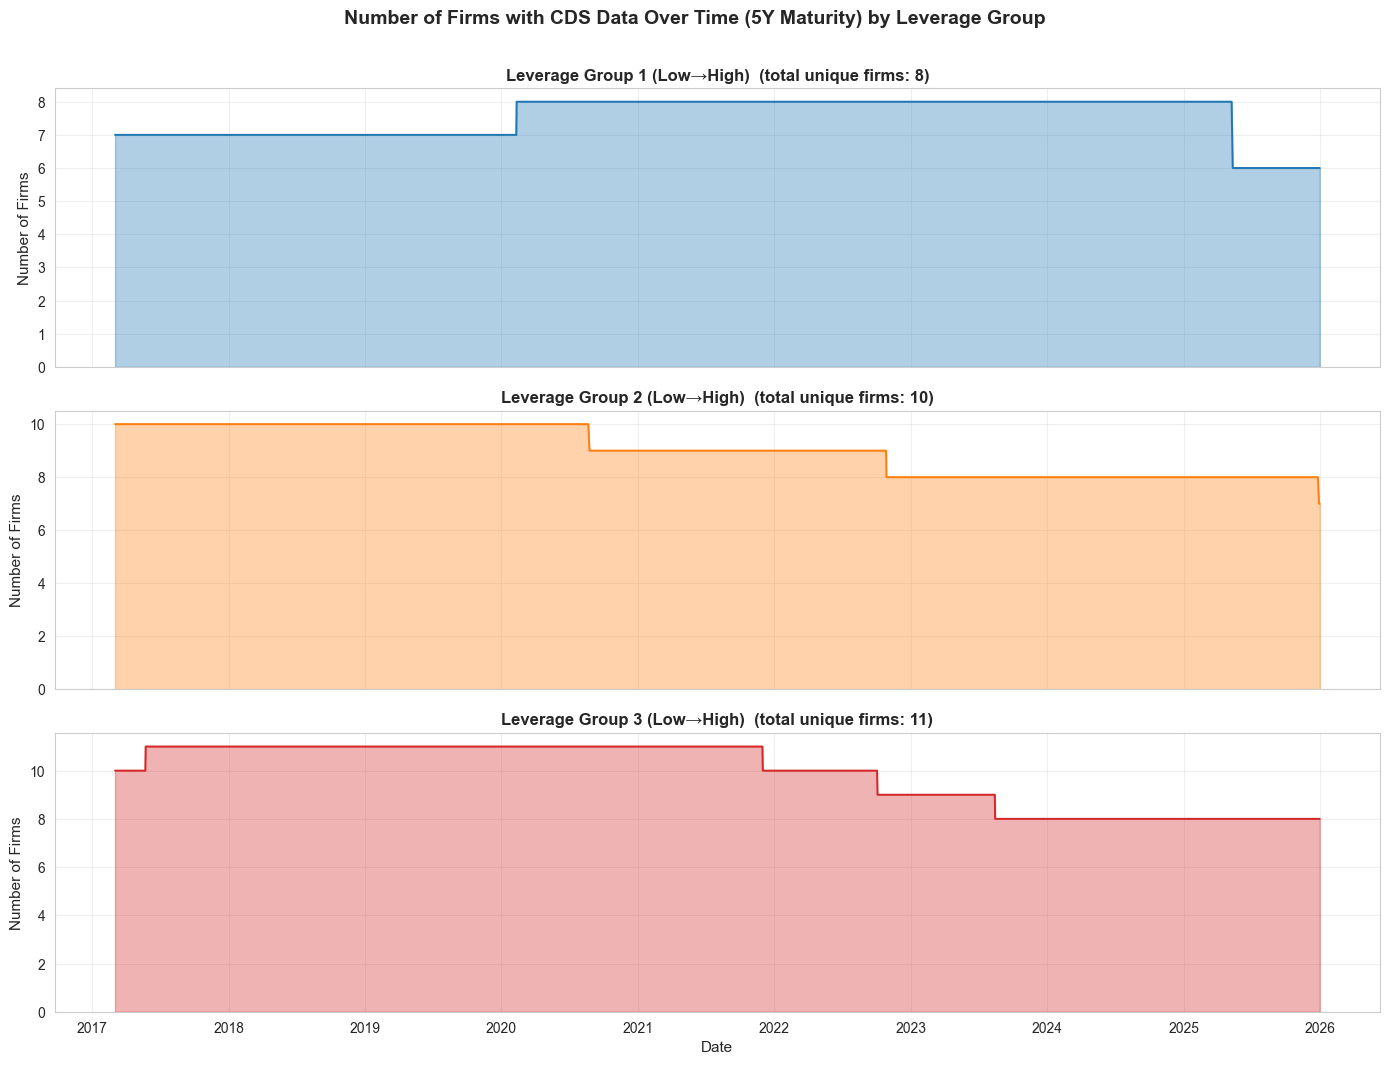

In [27]:
import matplotlib.dates as mdates

windows_path = Path('../data/cds_filters/gvkey_maturity_simulation_windows.csv')
windows = pd.read_csv(windows_path)
windows['gvkey'] = windows['gvkey'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
windows['maturity'] = windows['maturity'].astype(str).str.upper().str.strip()
windows['start_date'] = pd.to_datetime(windows['start_date'], errors='coerce')
windows['end_date'] = pd.to_datetime(windows['end_date'], errors='coerce')

merton_path = Path('../data/output/merged_data_with_merton.csv')
merton = pd.read_csv(merton_path, usecols=['gvkey', 'liabilities_total', 'mkt_cap'])
merton['gvkey'] = merton['gvkey'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
merton['leverage_value'] = merton['liabilities_total'] / merton['mkt_cap'].replace(0, np.nan)

firm_lev = (
    merton.dropna(subset=['leverage_value'])
    .groupby('gvkey', as_index=False)['leverage_value']
    .median()
)

n_groups = 3
quantiles = np.linspace(0, 1, n_groups + 1)
edges = np.unique(firm_lev['leverage_value'].quantile(quantiles).values)
actual = len(edges) - 1
group_names = [f'Leverage Group {i+1} (Low→High)' for i in range(actual)]
edges_adj = edges.copy()
edges_adj[0] -= 1e-12
edges_adj[-1] += 1e-12
firm_lev['leverage_group'] = pd.cut(
    firm_lev['leverage_value'], bins=edges_adj, labels=group_names, include_lowest=True,
)

windows = windows.merge(firm_lev[['gvkey', 'leverage_group', 'leverage_value']], on='gvkey', how='left')
windows = windows.dropna(subset=['leverage_group'])

maturity_label = '5Y'
mat_windows = windows[windows['maturity'] == maturity_label].copy()

all_dates = pd.bdate_range(
    start=mat_windows['start_date'].min(),
    end=mat_windows['end_date'].max(),
)

records = []
for _, row in mat_windows.iterrows():
    mask = (all_dates >= row['start_date']) & (all_dates <= row['end_date'])
    for d in all_dates[mask]:
        records.append({'date': d, 'gvkey': row['gvkey'], 'leverage_group': row['leverage_group']})

daily_panel = pd.DataFrame(records)
firm_counts = (
    daily_panel.groupby(['date', 'leverage_group'])['gvkey']
    .nunique()
    .rename('n_firms')
    .reset_index()
)

colors = {'Leverage Group 1 (Low→High)': 'tab:blue',
          'Leverage Group 2 (Low→High)': 'tab:orange',
          'Leverage Group 3 (Low→High)': 'tab:red'}

fig, axes = plt.subplots(actual, 1, figsize=(14, 3.5 * actual), sharex=True)
if actual == 1:
    axes = [axes]

for ax, gname in zip(axes, group_names):
    sub = firm_counts[firm_counts['leverage_group'] == gname].sort_values('date')
    total_firms = mat_windows[mat_windows['leverage_group'] == gname]['gvkey'].nunique()
    color = colors.get(gname, 'tab:gray')

    ax.fill_between(sub['date'], sub['n_firms'], alpha=0.35, color=color)
    ax.plot(sub['date'], sub['n_firms'], linewidth=1.4, color=color)
    ax.set_ylabel('Number of Firms', fontsize=11)
    ax.set_title(f'{gname}  (total unique firms: {total_firms})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

axes[-1].set_xlabel('Date', fontsize=11)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())

fig.suptitle(
    f'Number of Firms with CDS Data Over Time ({maturity_label} Maturity) by Leverage Group',
    fontsize=14, fontweight='bold', y=1.01,
)
fig.tight_layout()
plt.show()

## Firm Coverage Over Time

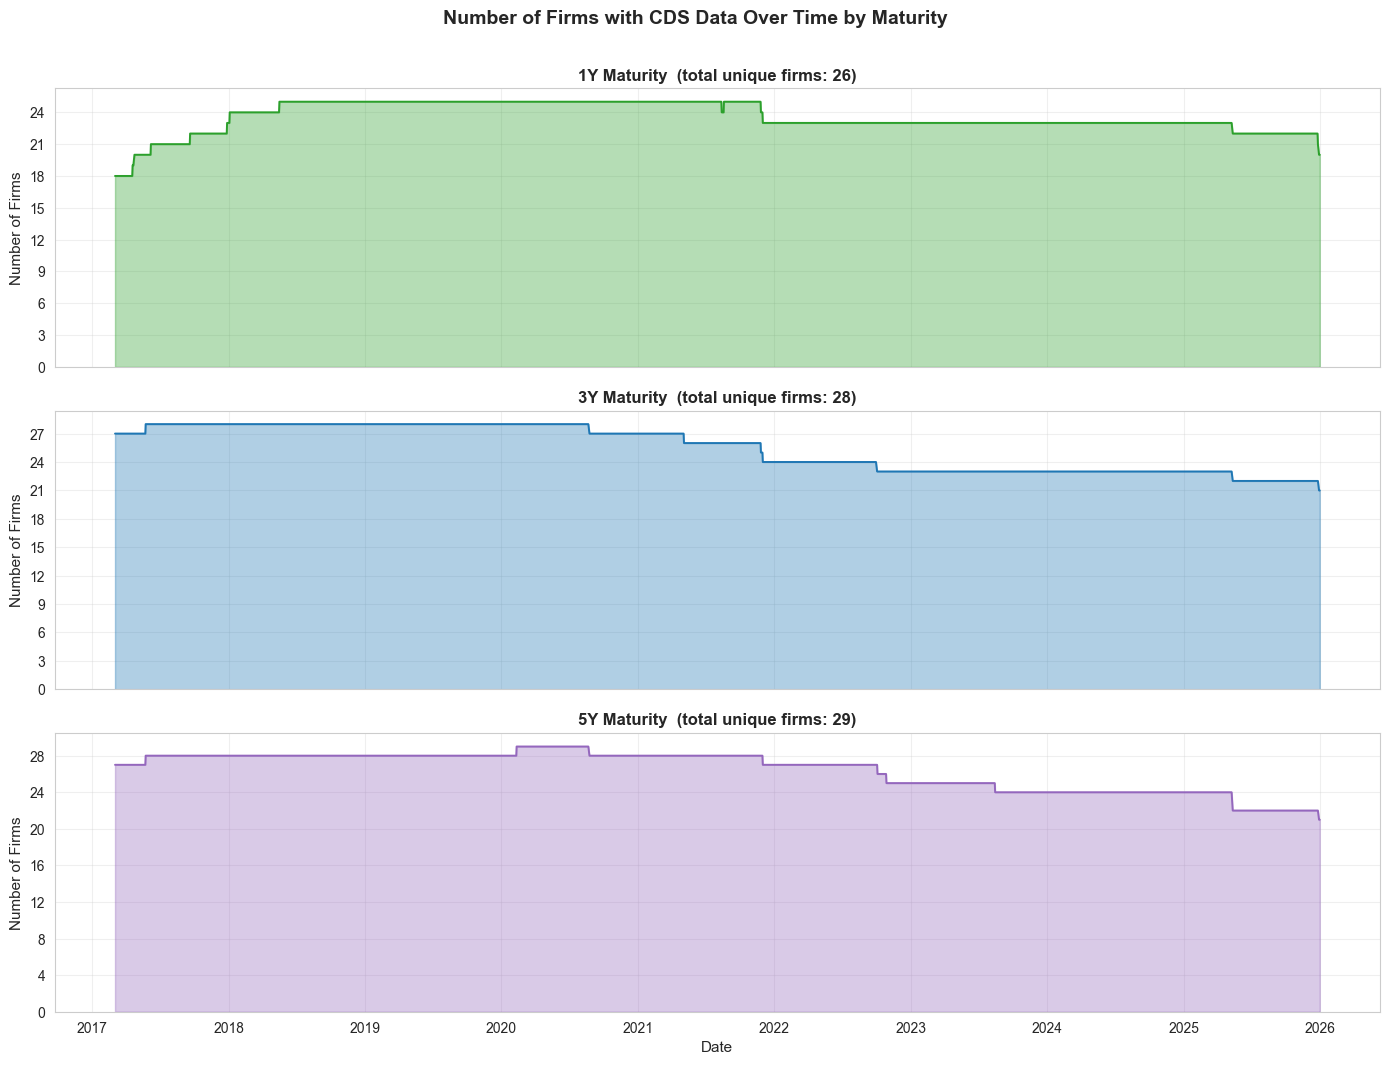

In [28]:
maturity_order = ['1Y', '3Y', '5Y']
mat_colors = {'1Y': 'tab:green', '3Y': 'tab:blue', '5Y': 'tab:purple'}

windows_all = pd.read_csv(windows_path)
windows_all['gvkey'] = windows_all['gvkey'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
windows_all['maturity'] = windows_all['maturity'].astype(str).str.upper().str.strip()
windows_all['start_date'] = pd.to_datetime(windows_all['start_date'], errors='coerce')
windows_all['end_date'] = pd.to_datetime(windows_all['end_date'], errors='coerce')

all_dates_mat = pd.bdate_range(
    start=windows_all['start_date'].min(),
    end=windows_all['end_date'].max(),
)

records_mat = []
for _, row in windows_all.iterrows():
    mask = (all_dates_mat >= row['start_date']) & (all_dates_mat <= row['end_date'])
    for d in all_dates_mat[mask]:
        records_mat.append({'date': d, 'gvkey': row['gvkey'], 'maturity': row['maturity']})

daily_panel_mat = pd.DataFrame(records_mat)
firm_counts_mat = (
    daily_panel_mat.groupby(['date', 'maturity'])['gvkey']
    .nunique()
    .rename('n_firms')
    .reset_index()
)

n_mat = len(maturity_order)
fig, axes = plt.subplots(n_mat, 1, figsize=(14, 3.5 * n_mat), sharex=True)
if n_mat == 1:
    axes = [axes]

for ax, mat in zip(axes, maturity_order):
    sub = firm_counts_mat[firm_counts_mat['maturity'] == mat].sort_values('date')
    total_firms = windows_all[windows_all['maturity'] == mat]['gvkey'].nunique()
    color = mat_colors.get(mat, 'tab:gray')

    ax.fill_between(sub['date'], sub['n_firms'], alpha=0.35, color=color)
    ax.plot(sub['date'], sub['n_firms'], linewidth=1.4, color=color)
    ax.set_ylabel('Number of Firms', fontsize=11)
    ax.set_title(f'{mat} Maturity  (total unique firms: {total_firms})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

axes[-1].set_xlabel('Date', fontsize=11)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())

fig.suptitle(
    'Number of Firms with CDS Data Over Time by Maturity',
    fontsize=14, fontweight='bold', y=1.01,
)
fig.tight_layout()
plt.show()